# Analisis Coastal Squeeze Mangrove Pantura Jawa (2021–2026)

**Nowcasting, forecasting, dan kerangka intervensi ruang gerak mundur mangrove berbasis transek**

Notebook ini menjalankan seluruh analisis dari data akhir di `code/dataset/` sampai rekomendasi intervensi
per transek dan per kawasan. Metode mengikuti [`coastal analyze guide.md`](coastal%20analyze%20guide.md);
setiap penyimpangan dari panduan ditandai **[Penyesuaian]** beserta alasannya.

## Pertanyaan penelitian

1. Di mana tepi mangrove bergerak mundur ke darat, dan seberapa cepat (nowcast Agustus 2026, forecast 6–12 bulan)?
2. Seberapa besar laju itu dijelaskan oleh **tekanan sisi laut** (amblesan, genangan) dan **tekanan sisi darat** (kawasan terbangun)?
3. Di transek mana ruang gerak mundur akan **habis** (coastal squeeze), dan di mana masih ada **ruang peluang** restorasi?
4. Intervensi apa yang tepat per transek dan per kawasan?

## Rantai sebab-akibat yang diuji

```
 TEKANAN SISI LAUT                     TEKANAN SISI DARAT
 amblesan Subs_i, genangan Inund_i     kawasan terbangun, tol/tanggul (B_hard)
            │                                   │
            ▼                                   ▼
 (Bag. 5) laju mundur tepi v_i  ──►  ruang gerak MS_i,t = B_hard − Y_i,t  ◄── (Bag. 3) posisi penghalang
            │                                   │
            └──────────────►  (Bag. 6) P(Closed_h): peluang MS ≤ 0 dalam h tahun
                                                │
            ruang peluang tambak/lahan terbuka ─┤──►  RFI (kelayakan restorasi)
            penduduk terpapar ──────────────────┤──►  PERI (risiko keterpaparan)
                                                ▼
                         (Bag. 7) hotspot Gi*, tipologi 4 aksi, kawasan prioritas
                                                ▼
                         (Bag. 8) uji ketahanan terhadap pilihan ambang
```

Setiap bagian memakai keluaran bagian sebelumnya, sehingga masalah data yang ditemukan di Bagian 2
bisa ditelusuri dampaknya sampai ke rekomendasi akhir.

## Peta isi

| Bagian | Isi | Keluaran kunci |
|---|---|---|
| 1 | Setup dan parameter | konstanta, fungsi bantu |
| 2 | Pemahaman data | dimensi, integritas, kekosongan, hubungan, **daftar masalah data** |
| 3 | Operasionalisasi variabel | kalibrasi ambang, domain mangrove, Y_i,t, B_hard, B_soft, MS |
| 4 | Nowcast dan forecast | Kalman local linear trend, backtest vs baseline |
| 5 | Laju mundur dan dua tekanan | v_i, regresi dekomposisi tekanan |
| 6 | Risiko dan kelayakan | P(Closed_1), P(Closed_5), RFI, PERI |
| 7 | Intervensi multi-skala | Getis-Ord Gi*, tipologi 4 aksi, kawasan prioritas |
| 8 | Uji sensitivitas | 36 skenario ambang + uji tambahan |
| 9 | Sintesis | rantai sebab-akibat dengan angka, keterbatasan, ekspor |

## 1. Setup dan parameter

Semua ambang dikumpulkan di satu tempat (`PARAM`) supaya uji sensitivitas di Bagian 8 cukup mengubah nilai di sini.
Nilai awal mengikuti panduan, kecuali yang ditandai; alasan setiap penyesuaian ditunjukkan dengan data di Bagian 3.

In [1]:
import warnings, time, json
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import optimize
from scipy.stats import norm, spearmanr, kruskal
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.ensemble import HistGradientBoostingRegressor

warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 170); pd.set_option("display.max_columns", 40); pd.set_option("display.precision", 3)
sns.set_theme(style="whitegrid", context="notebook", font_scale=0.95)

CODE = Path.cwd().parent if Path.cwd().name == "analisis" else Path.cwd()
DS, GEE = CODE / "dataset", CODE / "dataset" / "gee"
TUR = DS / "turunan"            # cache turunan (tensor profil, Y bulanan)
HASIL = CODE / "analisis" / "hasil"   # gambar dan tabel keluaran
TUR.mkdir(exist_ok=True); HASIL.mkdir(exist_ok=True)

REG = ["PKL", "SEM", "CIR", "SBY", "JPR"]
REG_NAMA = {"PKL": "Pekalongan", "SEM": "Semarang–Demak", "CIR": "Cirebon", "SBY": "Surabaya", "JPR": "Jepara (kontrol)"}
REG_WARNA = dict(zip(REG, sns.color_palette("tab10", 5)))
BULAN = pd.period_range("2021-01", "2026-08", freq="M"); T = len(BULAN)
TAHUN = np.arange(2021, 2027); TH_T = BULAN.year.to_numpy()        # tahun tiap langkah waktu
STEP, LEN_SEA, P = 10, 500, 351; DIST = np.arange(P) * STEP        # dist_m: 0 = ujung laut, 500 = garis pantai
KELAS_DW = ["water", "trees", "crops", "built", "bare", "floodveg"]

PARAM = dict(
    TAU_VEG=0.4,      # NDVI minimum kanopi (panduan 0,4)
    TAU_SAR=-16.0,    # [Penyesuaian] VH minimum (dB); panduan -14 dB -> lihat kalibrasi Bagian 3.1
    TAU_BUILT=0.5,    # P(built) Dynamic World untuk penghalang keras (panduan 0,5)
    MAXY=1500,        # tepi dicari sampai dist_m 1500 (1 km ke darat dari garis pantai basis)
    RUN=3,            # tepi = awal rangkaian >= 3 titik (30 m) berturut-turut
    MINVALID=0.8,     # bulan dipakai bila >= 80% titik 0..MAXY punya NDVI dan VH
    BUILT_RUN=2,      # penghalang keras DW = >= 2 titik (20 m) berturut-turut
    SIGMA_B=10.0,     # ketidakpastian posisi penghalang (m) = 1 piksel
    SUBS_HIGH=1.0,    # cm/th: amblesan melampaui laju akresi vertikal mangrove (+-1 cm/th)
    MS_DEKAT=500.0,   # m: penghalang keras dalam 500 m dari tepi = tekanan darat tinggi
)
T0_BACKTEST = list(BULAN).index(pd.Period("2023-08", "M"))   # origin pertama backtest

def simpan(nama):
    plt.savefig(HASIL / f"{nama}.png", dpi=130, bbox_inches="tight")

def tabel(df, nama):
    df.to_csv(HASIL / f"{nama}.csv", index=True); return df

print("CODE :", CODE); print("T =", T, "bulan:", BULAN[0], "s.d.", BULAN[-1])

CODE : C:\Users\ASUS\Documents\Lomba\ARSEN 2026\mangrove\code
T = 68 bulan: 2021-01 s.d. 2026-08


## 2. Pemahaman data

Bagian ini menjawab: data apa yang tersedia, berapa dimensinya, apakah kuncinya konsisten, di mana datanya
kosong, bagaimana variabel saling berhubungan, dan **masalah apa yang akan memengaruhi analisis**.

### 2.1 Inventaris dataset

In [2]:
inv = []
for f in sorted(DS.glob("*.csv")) + sorted(DS.glob("*.json")) + sorted(DS.glob("*.geojson")):
    inv.append(dict(file=f.name, lokasi="dataset/", MB=round(f.stat().st_size / 1e6, 2)))
for pola in ["profil_s2_*.csv", "profil_s1_*.csv", "statis_*.csv", "rgb_s2_*.tif"]:
    fs = sorted(GEE.glob(pola))
    inv.append(dict(file=pola, lokasi=f"dataset/gee/ ({len(fs)} file)", MB=round(sum(f.stat().st_size for f in fs) / 1e6, 1)))
inv = pd.DataFrame(inv)
print(f"{len(inv)} entri, total {inv.MB.sum():,.0f} MB"); inv

33 entri, total 1,748 MB


,file,lokasi,MB
0,gnss_laju_amblesan.csv,dataset/,0.00
1,hard_barrier_dw.csv,dataset/,0.02
2,hard_barrier_persilangan.csv,dataset/,0.14
3,pasut_akuisisi.csv,dataset/,0.80
4,pasut_statistik.csv,dataset/,0.00
5,pop_worldpop_1km.csv,dataset/,0.11
6,s1_akuisisi_CIR.csv,dataset/,0.01
7,s1_akuisisi_JPR.csv,dataset/,0.01
8,s1_akuisisi_PKL.csv,dataset/,0.02
9,s1_akuisisi_SBY.csv,dataset/,0.02


### 2.2 Memuat data ke tensor

Data profil disimpan per titik sampel (transek × `dist_m`), satu kolom per bulan. Untuk analisis, data diubah
menjadi **tensor** `[transek, titik, waktu]` setelah diurutkan menurut `(transek_id, dist_m)`. Urutan baris di
file S1 dan S2 **tidak sama**, sehingga penggabungan tanpa pengurutan akan salah pasang titik.
Hasilnya disimpan di `dataset/turunan/` supaya pemuatan berikutnya cepat.

In [3]:
KEY = ["transek_id", "dist_m"]

def baca_paket(pola, prefix):
    cols = None; parts = []
    for f in sorted(GEE.glob(pola)):
        if cols is None:
            head = pd.read_csv(f, nrows=0).columns
            cols = KEY + [c for c in head if c.split("_")[0] in prefix]
        parts.append(pd.read_csv(f, usecols=cols))
    return pd.concat(parts, ignore_index=True).sort_values(KEY, ignore_index=True)

f_cache = TUR / "tensor_profil.npz"
t0 = time.time()
if not f_cache.exists():
    s2 = baca_paket("profil_s2_*.csv", ["ndvi", "mndwi", "n"])
    s1 = baca_paket("profil_s1_*.csv", ["vv", "vh"])
    stt = pd.concat([pd.read_csv(f) for f in sorted(GEE.glob("statis_*.csv"))]).sort_values(KEY, ignore_index=True)
    assert (s2[KEY].values == s1[KEY].values).all() and (s2[KEY].values == stt[KEY].values).all()
    ids = s2.transek_id.unique(); N = len(ids)
    def tens(df, pre, skala):
        c = [f"{pre}_{p.strftime('%Y%m')}" for p in BULAN]
        return (df[c].to_numpy(np.float32) / skala).reshape(N, P, T)
    dw = np.stack([np.stack([stt[f"dw_{k}_{y}"].to_numpy(np.float32) / 1000 for k in KELAS_DW], -1) for y in TAHUN], 1)  # [titik, tahun, kelas]
    np.savez(f_cache, ids=ids, NDVI=tens(s2, "ndvi", 1000), MNDWI=tens(s2, "mndwi", 1000),
             NOBS=tens(s2, "n_ndvi", 1), VV=tens(s1, "vv", 100), VH=tens(s1, "vh", 100),
             DW=dw.reshape(N, P, len(TAHUN), len(KELAS_DW)),
             INUND=(stt.inund_freq.to_numpy(np.float32) / 1000).reshape(N, P),
             INUND_Y=np.stack([stt[f"inund_freq_{y}"].to_numpy(np.float32) / 1000 for y in TAHUN], -1).reshape(N, P, len(TAHUN)),
             TIDEC=(stt.tide_coupling.to_numpy(np.float32) / 1000).reshape(N, P),
             ELEV=(stt.elev_glo30_cm.to_numpy(np.float32) / 100).reshape(N, P))
    del s2, s1, stt
z = np.load(f_cache, allow_pickle=True)
IDS = z["ids"]; N = len(IDS)
NDVI, MNDWI, NOBS, VV, VH = z["NDVI"], z["MNDWI"], z["NOBS"], z["VV"], z["VH"]
DW, INUND, INUND_Y, TIDEC, ELEV = z["DW"], z["INUND"], z["INUND_Y"], z["TIDEC"], z["ELEV"]
print(f"tensor dimuat dalam {time.time() - t0:.0f} s")

# tabel tingkat transek
TR = pd.read_csv(DS / "transek_params_final.csv").set_index("transek_id").loc[IDS]
TR = TR.join(pd.read_csv(DS / "subs_insar_transek.csv").set_index("transek_id").drop(columns="region_code"))
TR = TR.join(pd.read_csv(DS / "pop_worldpop_1km.csv").set_index("transek_id"))
xy = gpd.GeoSeries(gpd.points_from_xy(TR.cx, TR.cy), crs=32749).to_crs(4326)
TR["lon"], TR["lat"] = xy.x.values, xy.y.values
REG_I = TR.region_code.to_numpy()

# WorldCover 2021 (referensi mangrove independen, langkah akuisisi 9a)
wc = pd.read_csv(DS / "worldcover_2021_transek.csv").sort_values(KEY)
assert (wc.transek_id.to_numpy()[::P] == IDS).all()
WC = wc.wc2021.to_numpy().reshape(N, P)

# persilangan penghalang (OSM + konstruksi + Dynamic World baru)
BAR = pd.concat([pd.read_csv(DS / "hard_barrier_persilangan.csv"),
                 pd.read_csv(DS / "hard_barrier_dw.csv").drop(columns="lebar_m")], ignore_index=True)
GN = pd.read_csv(DS / "gnss_laju_amblesan.csv")

tensor dimuat dalam 4 s


### 2.3 Deklarasi dimensi

Unit analisis adalah **transek** $i$; setiap transek punya 351 titik sampel $x$ (tiap 10 m) dan 68 langkah waktu
bulanan $t$. Tabel berikut adalah "kontrak" dimensi yang dipakai semua bagian berikutnya.

In [4]:
dim = pd.DataFrame([
    ("Transek (i)", N, "unit analisis, spasi 250 m"),
    ("Titik per transek (x)", P, "0 = ujung laut, 500 = garis pantai basis, 3.500 = ujung darat; tiap 10 m"),
    ("Langkah waktu (t)", T, f"bulanan {BULAN[0]} – {BULAN[-1]}"),
    ("Tahun (tutupan lahan, genangan)", len(TAHUN), "2021–2026 (2026 = Jan–Agu)"),
    ("Titik sampel total (i × x)", N * P, "baris di file profil/statis"),
    ("Observasi ruang-waktu (i × x × t)", N * P * T, "per variabel bulanan (NDVI, MNDWI, VV, VH)"),
    ("Observasi transek-bulan (i × t)", N * T, "unit deret Y_i,t sebelum pembatasan domain"),
], columns=["dimensi", "ukuran", "keterangan"]).set_index("dimensi")
display(dim)

var = pd.DataFrame([
    ("NDVI", NDVI.shape, "S2 median bulanan", "kanopi -> tepi mangrove"),
    ("MNDWI", MNDWI.shape, "S2 median bulanan", "air permukaan (deskriptif)"),
    ("VH", VH.shape, "S1 descending, dB", "struktur kanopi -> tepi mangrove"),
    ("VV", VV.shape, "S1 descending, dB", "permukaan air (deskriptif)"),
    ("NOBS", NOBS.shape, "jumlah citra S2 bersih", "kualitas observasi"),
    ("DW", DW.shape, "P(kelas) Dynamic World per tahun", "penghalang keras, tambak, domain"),
    ("INUND / INUND_Y", f"{INUND.shape} / {INUND_Y.shape}", "frekuensi genangan S1", "tekanan laut, jendela hidroperiode"),
    ("ELEV", ELEV.shape, "GLO-30 (m)", "filter kasar saja"),
    ("WC", WC.shape, "kelas ESA WorldCover 2021", "referensi mangrove"),
    ("TR", TR.shape, "tabel transek", "Subs_i, Pop_i, koordinat"),
], columns=["variabel", "bentuk", "isi", "peran"]).set_index("variabel")
display(var)
print("Transek per wilayah:", TR.region_code.value_counts().reindex(REG).to_dict())

,ukuran,keterangan
dimensi,,
Transek (i),2365,"unit analisis, spasi 250 m"
Titik per transek (x),351,"0 = ujung laut, 500 = garis pantai basis, 3.50..."
Langkah waktu (t),68,bulanan 2021-01 – 2026-08
"Tahun (tutupan lahan, genangan)",6,2021–2026 (2026 = Jan–Agu)
Titik sampel total (i × x),830115,baris di file profil/statis
Observasi ruang-waktu (i × x × t),56447820,"per variabel bulanan (NDVI, MNDWI, VV, VH)"
Observasi transek-bulan (i × t),160820,"unit deret Y_i,t sebelum pembatasan domain"


,bentuk,isi,peran
variabel,,,
NDVI,"(2365, 351, 68)",S2 median bulanan,kanopi -> tepi mangrove
MNDWI,"(2365, 351, 68)",S2 median bulanan,air permukaan (deskriptif)
VH,"(2365, 351, 68)","S1 descending, dB",struktur kanopi -> tepi mangrove
VV,"(2365, 351, 68)","S1 descending, dB",permukaan air (deskriptif)
NOBS,"(2365, 351, 68)",jumlah citra S2 bersih,kualitas observasi
DW,"(2365, 351, 6, 6)",P(kelas) Dynamic World per tahun,"penghalang keras, tambak, domain"
INUND / INUND_Y,"(2365, 351) / (2365, 351, 6)",frekuensi genangan S1,"tekanan laut, jendela hidroperiode"
ELEV,"(2365, 351)",GLO-30 (m),filter kasar saja
WC,"(2365, 351)",kelas ESA WorldCover 2021,referensi mangrove


Transek per wilayah: {'PKL': 290, 'SEM': 315, 'CIR': 405, 'SBY': 1165, 'JPR': 190}


### 2.4 Integritas kunci

In [5]:
cek = {
    "setiap transek punya 351 titik": bool((wc.groupby("transek_id").size() == P).all()),
    "transek_id unik di tabel transek": TR.index.is_unique,
    "semua transek punya nilai populasi": bool(TR.pop_2026.notna().all()),
    "transek dengan Subs_i (InSAR)": f"{TR.subs_cm_th.notna().sum()} / {N}",
    "persilangan penghalang merujuk transek yang ada": bool(BAR.transek_id.isin(IDS).all()),
    "rentang NDVI dalam [-1, 1]": bool(np.nanmin(NDVI) >= -1 and np.nanmax(NDVI) <= 1),
    "rentang VH (dB)": f"{np.nanmin(VH):.1f} s.d. {np.nanmax(VH):.1f}",
}
pd.Series(cek, name="hasil").to_frame()

,hasil
setiap transek punya 351 titik,True
transek_id unik di tabel transek,True
semua transek punya nilai populasi,True
transek dengan Subs_i (InSAR),2121 / 2365
persilangan penghalang merujuk transek yang ada,True
"rentang NDVI dalam [-1, 1]",True
rentang VH (dB),-52.0 s.d. 17.9


### 2.5 Pola kekosongan data

Kekosongan data bukan sekadar persentase: **polanya** menentukan cara penanganannya. Kekosongan acak (awan)
bisa diabaikan model state-space, sedangkan kekosongan terstruktur (seluruh wilayah kosong satu bulan) membuat
celah deret waktu yang harus dijembatani.

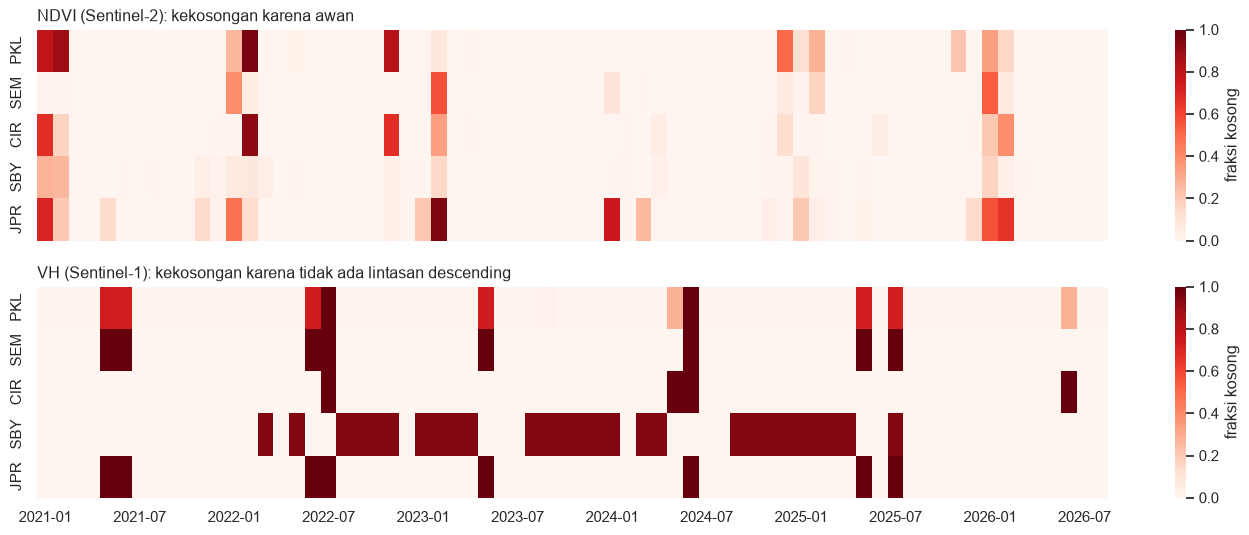

,NDVI kosong (rata2),bulan NDVI kosong >50%,VH kosong (rata2),bulan VH kosong >50%
PKL,0.080,4,0.112,8
SEM,0.030,2,0.118,8
CIR,0.054,3,0.059,4
SBY,0.021,0,0.376,27
JPR,0.084,5,0.118,8


In [6]:
miss_ndvi = pd.DataFrame({r: np.isnan(NDVI[REG_I == r]).mean(axis=(0, 1)) for r in REG}, index=BULAN.astype(str))
miss_vh = pd.DataFrame({r: np.isnan(VH[REG_I == r]).mean(axis=(0, 1)) for r in REG}, index=BULAN.astype(str))
fig, ax = plt.subplots(2, 1, figsize=(14, 5.5), sharex=True)
for a, m, jud in [(ax[0], miss_ndvi, "NDVI (Sentinel-2): kekosongan karena awan"),
                  (ax[1], miss_vh, "VH (Sentinel-1): kekosongan karena tidak ada lintasan descending")]:
    sns.heatmap(m.T, ax=a, cmap="Reds", vmin=0, vmax=1, cbar_kws=dict(label="fraksi kosong"))
    a.set_title(jud, loc="left"); a.set_ylabel("")
ax[1].set_xticks(np.arange(0, T, 6) + 0.5); ax[1].set_xticklabels(BULAN.astype(str)[::6], rotation=0)
plt.tight_layout(); simpan("02_pola_kekosongan"); plt.show()

ring = pd.DataFrame({
    "NDVI kosong (rata2)": miss_ndvi.mean(), "bulan NDVI kosong >50%": (miss_ndvi > 0.5).sum(),
    "VH kosong (rata2)": miss_vh.mean(), "bulan VH kosong >50%": (miss_vh > 0.5).sum()})
tabel(ring.round(3), "02_ringkasan_kekosongan")

**Interpretasi.** Kedua sensor kosong dengan pola yang berbeda:

- **NDVI (awan)** kosong musiman: bulan dengan > 30% titik kosong jatuh pada Desember–Februari (misalnya Jan 2021,
  Feb 2022, Jan 2026). SBY hampir tidak pernah kosong.
- **VH (lintasan)** kosong **terstruktur**: PKL, SEM, dan JPR kosong pada bulan yang sama (Mei–Juli beberapa tahun),
  karena ketiganya berbagi orbit descending 76. SBY kosong 27 dari 68 bulan, tersebar di semua musim: orbit
  descending yang dipilih untuk SBY tidak meliput setiap bulan.

Konsekuensinya, deret $Y_{i,t}$ memerlukan model yang bisa melewati bulan kosong tanpa mengisinya dengan tebakan
(Bagian 4), dan ketidakpastian di SBY akan lebih besar di bulan-bulan tanpa lintasan.

### 2.6 Hubungan antarvariabel: apakah sinyal satelit bisa membedakan mangrove?

Tepi mangrove $Y_{i,t}$ dideteksi dari NDVI dan VH. Sebelum dipakai, perlu dicek bagaimana kedua sinyal itu
tersebar pada kelas lahan (Dynamic World 2022) dan pada mangrove menurut ESA WorldCover 2021.

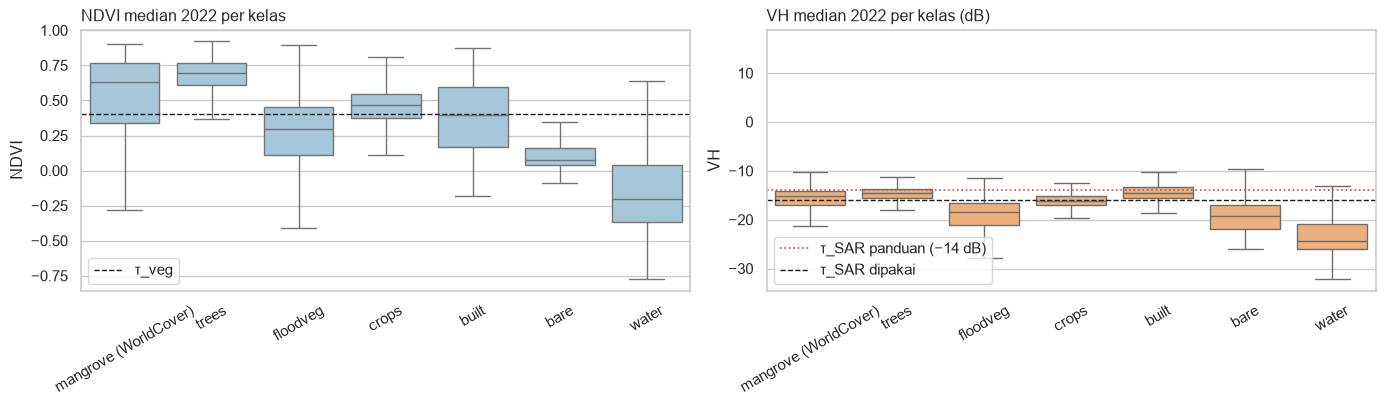

NDVI                 VH              
                        0.1   0.5   0.9    0.1    0.5    0.9
kelas                                                       
mangrove (WorldCover)  0.12  0.63  0.82 -19.02 -15.14 -13.41
trees                  0.51  0.70  0.82 -16.48 -14.59 -13.10
floodveg              -0.08  0.30  0.60 -23.47 -18.45 -15.12
crops                  0.30  0.47  0.62 -17.92 -16.08 -14.55
built                  0.07  0.40  0.70 -16.50 -14.51 -11.67
bare                   0.01  0.08  0.27 -24.03 -19.16 -14.39
water                 -0.48 -0.20  0.25 -27.06 -24.41 -18.04

In [7]:
th22 = TH_T == 2022
ndvi22 = np.nanmedian(NDVI[:, :, th22], axis=2); vh22 = np.nanmedian(VH[:, :, th22], axis=2)
dom22 = np.array(KELAS_DW)[DW[:, :, 1, :].argmax(-1)]
kelas = np.where(WC == 95, "mangrove (WorldCover)", dom22)
d = pd.DataFrame(dict(kelas=kelas.ravel(), NDVI=ndvi22.ravel(), VH=vh22.ravel(),
                      sisi=np.where(np.tile(DIST, N) < LEN_SEA, "laut", "darat"))).dropna()
d = d.sample(200_000, random_state=1)
urut = ["mangrove (WorldCover)", "trees", "floodveg", "crops", "built", "bare", "water"]
fig, ax = plt.subplots(1, 2, figsize=(14, 4.2))
sns.boxplot(d, x="kelas", y="NDVI", order=urut, ax=ax[0], fliersize=0, color="#9ecae1")
sns.boxplot(d, x="kelas", y="VH", order=urut, ax=ax[1], fliersize=0, color="#fdae6b")
ax[0].axhline(PARAM["TAU_VEG"], c="k", ls="--", lw=1, label="τ_veg")
ax[1].axhline(-14, c="r", ls=":", lw=1.2, label="τ_SAR panduan (−14 dB)")
ax[1].axhline(PARAM["TAU_SAR"], c="k", ls="--", lw=1, label="τ_SAR dipakai")
for a in ax: a.tick_params(axis="x", rotation=30); a.legend(loc="lower left"); a.set_xlabel("")
ax[0].set_title("NDVI median 2022 per kelas", loc="left"); ax[1].set_title("VH median 2022 per kelas (dB)", loc="left")
plt.tight_layout(); simpan("02_ndvi_vh_per_kelas"); plt.show()
q = d.groupby("kelas")[["NDVI", "VH"]].quantile([0.1, 0.5, 0.9]).unstack().loc[urut].round(2)
q

**Interpretasi.** Mangrove (WorldCover) punya median NDVI 0,63 dan VH −15,1 dB, sedangkan pohon darat 0,70 dan
−14,6 dB. Sebarannya **bertumpang tindih**: NDVI + VH memisahkan vegetasi dari air/lahan terbuka dengan baik
(air: NDVI −0,20, VH −24,4 dB), tetapi tidak memisahkan mangrove dari pohon/sawah pesisir. Ambang VH panduan
(−14 dB) juga berada **di atas** median VH mangrove, sehingga lebih dari separuh piksel mangrove akan gagal lolos.
Dua temuan ini (masalah M3 dan M4) dikoreksi di Bagian 3.1–3.2.

**Hubungan di tingkat transek.** Kovariat tekanan dihitung di Bagian 3 dan 5, tetapi hubungan antar kovariat
mentahnya (amblesan, penduduk, keberadaan mangrove, multi-persilangan pantai) sudah bisa dilihat di sini untuk
mendeteksi kolinearitas dan perbedaan antarwilayah sejak awal.

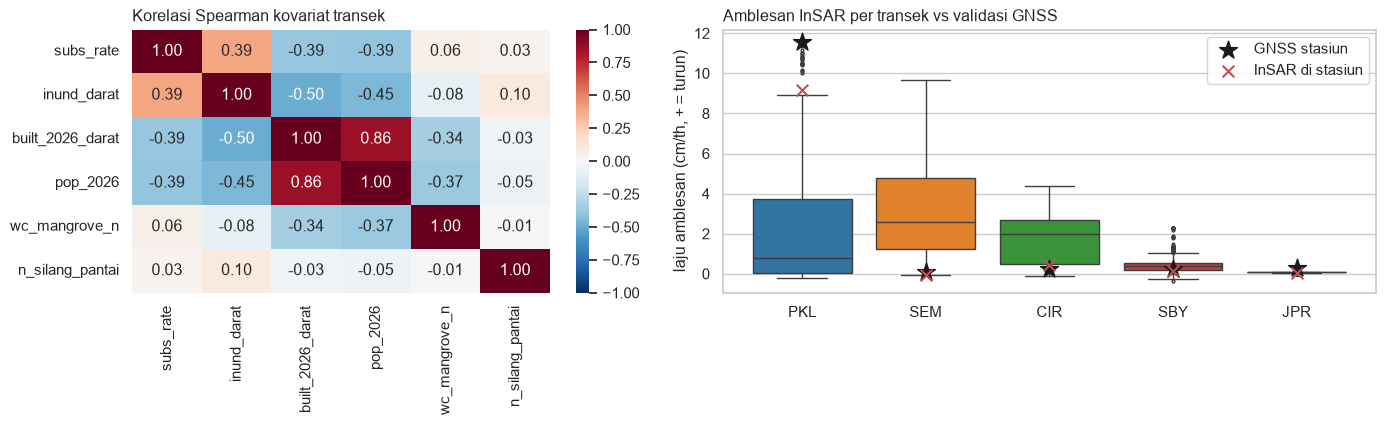

,transek,subs_median,subs_p90,subs_kosong,pop_median,transek_mangrove_WC,multi_silang
region_code,,,,,,,
PKL,290,0.77,6.80,0.05,480.0,0.06,0.01
SEM,315,2.58,7.90,0.08,56.9,0.34,0.14
CIR,405,2.00,3.26,0.09,25.8,0.10,0.06
SBY,1165,0.37,0.64,0.14,1110.7,0.46,0.08
JPR,190,0.08,0.09,0.03,466.5,0.02,0.09


In [8]:
TR["wc_mangrove_n"] = (WC[:, : PARAM["MAXY"] // STEP + 1] == 95).sum(1)
TR["built_2026_darat"] = DW[:, 50:151, 5, 3].mean(1)          # rerata P(built) 0-1 km ke darat
TR["inund_darat"] = INUND[:, 50:71].mean(1)                    # genangan 0-200 m ke darat
TR["subs_rate"] = -TR.subs_cm_th                               # + = tanah turun (cm/th)
kov = TR[["subs_rate", "inund_darat", "built_2026_darat", "pop_2026", "wc_mangrove_n", "n_silang_pantai"]]
fig, ax = plt.subplots(1, 2, figsize=(14, 4.4), gridspec_kw=dict(width_ratios=[1, 1.25]))
sns.heatmap(kov.corr("spearman"), annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1, ax=ax[0])
ax[0].set_title("Korelasi Spearman kovariat transek", loc="left")
sns.boxplot(TR, x="region_code", y="subs_rate", order=REG, ax=ax[1], palette=REG_WARNA, fliersize=2)
g = GN.set_index("region_code").loc[REG]
ax[1].scatter(range(5), -g.laju_cm_th, marker="*", s=180, c="k", zorder=5, label="GNSS stasiun")
ax[1].scatter(range(5), -g.vlm_insar_stasiun_cm_th, marker="x", s=70, c="r", zorder=5, label="InSAR di stasiun")
ax[1].set_ylabel("laju amblesan (cm/th, + = turun)"); ax[1].legend(); ax[1].set_xlabel("")
ax[1].set_title("Amblesan InSAR per transek vs validasi GNSS", loc="left")
plt.tight_layout(); simpan("02_kovariat_transek"); plt.show()
ringkas_reg = TR.groupby("region_code").agg(
    transek=("cx", "size"), subs_median=("subs_rate", "median"), subs_p90=("subs_rate", lambda s: s.quantile(0.9)),
    subs_kosong=("subs_rate", lambda s: s.isna().mean()), pop_median=("pop_2026", "median"),
    transek_mangrove_WC=("wc_mangrove_n", lambda s: (s >= 3).mean()), multi_silang=("n_silang_pantai", lambda s: (s > 1).mean())
).loc[REG]
tabel(ringkas_reg.round(2), "02_ringkasan_wilayah")

**Interpretasi.**

- **Amblesan berbeda tajam antarwilayah** dan sesuai desain arketipe: SEM (median 2,6 cm/th, 10% transek ≥ 7,9)
  dan CIR (2,0) tertinggi; PKL bermedian rendah (0,8) tetapi berekor ekstrem (p90 6,8); SBY (0,4) dan JPR (0,1)
  rendah. InSAR di lokasi stasiun cocok dengan GNSS (PKL −9,2 vs −11,6 cm/th; stasiun lain |selisih| ≤ 0,3), sehingga
  InSAR layak dipakai per transek.
- **Kawasan terbangun dan penduduk berkorelasi sangat kuat** (ρ = 0,86). Memasukkan keduanya ke satu model akan
  menghitung informasi yang sama dua kali; karena itu terbangun hanya dipakai di model tekanan (Bagian 5) dan
  penduduk hanya di PERI (Bagian 6).
- Amblesan berkorelasi sedang dengan genangan (ρ = 0,39) dan negatif dengan terbangun (ρ = −0,39): kawasan paling
  ambles adalah kawasan tambak, bukan kota. Kolinearitas ini dicek ulang (VIF) di Bagian 5.
- **Mangrove langka di PKL (6%), CIR (10%), dan JPR (2%)** menurut WorldCover. Laju tepi hanya bisa diukur di
  transek bermangrove, sehingga bobot sampel analisis tepi didominasi SBY dan SEM.

### 2.7 Masalah data dan dampaknya pada analisis

Tabel ini merangkum temuan 2.4–2.6. Kolom *penanganan* menunjukkan di bagian mana masalah itu diselesaikan,
sehingga dampaknya bisa ditelusuri.

In [9]:
masalah = pd.DataFrame([
    ("M1", "VH kosong terstruktur", f"SBY {int(ring.loc['SBY','bulan VH kosong >50%'])} bulan, wilayah lain 4–8 bulan tanpa lintasan descending",
     "Y_i,t tidak terukur pada bulan itu; deret berlubang", "Bag. 4: Kalman memprediksi melewati celah; varians membesar di bulan kosong"),
    ("M2", "NDVI kosong musiman (awan)", f"hingga {miss_ndvi.max().max():.0%} titik kosong pada puncak musim hujan",
     "tepi palsu ke darat bila mangrove tertutup awan", "Bag. 3: bulan dipakai hanya bila >= 80% titik valid; filter pencilan Hampel"),
    ("M3", "Ambang VH panduan terlalu tinggi", "median VH mangrove ≈ −14 dB = ambang panduan",
     "separuh tegakan mangrove hilang dari deteksi", "Bag. 3.1: τ_SAR dikalibrasi terhadap WorldCover"),
    ("M4", "NDVI+VH tidak membedakan mangrove dari pohon/sawah pesisir", "pohon darat: NDVI 0,70, VH −14,6 dB (mirip mangrove)",
     "keberadaan mangrove terlalu tinggi (presisi ≤ 0,46)", "Bag. 3.2: domain mangrove dari WorldCover 2021"),
    ("M5", "Mangrove langka di wilayah kontrol", f"JPR: {ringkas_reg.loc['JPR','transek_mangrove_WC']:.0%} transek bermangrove",
     "Jepara lemah sebagai kontrol untuk laju tepi", "Bag. 5: kontrol memakai kovariat kontinu, bukan label wilayah"),
    ("M6", "Subs_i kosong", f"{TR.subs_rate.isna().mean():.0%} transek tanpa titik InSAR (koherensi rendah di tambak)",
     "transek terbuang dari regresi dan RFI", "Bag. 5: imputasi median tetangga ≤ 1 km, ditandai"),
    ("M7", "Periode InSAR 2017–2023", "hanya beririsan 2021–2023 dengan periode studi",
     "Subs_i dianggap laju persisten", "dinyatakan sebagai asumsi (Bag. 9)"),
    ("M8", "Penghalang di ujung transek tidak teramati", "transek 3,5 km; penghalang > 3.500 m tidak terlihat",
     "MS_i tersensor kanan (batas bawah)", "Bag. 3.4: ditandai B_tersensor; P(Closed) konservatif (terlalu kecil)"),
    ("M9", "Transek multi-persilangan pantai", f"{(TR.n_silang_pantai > 1).mean():.0%} transek",
     "Y_i,t bisa melompat antar garis pantai", "Bag. 8: analisis ulang tanpa transek ini"),
    ("M10", "Belum ada digitasi validasi manual", "langkah 9 akuisisi belum dikerjakan",
     "akurasi Y_i,t hanya diuji terhadap WorldCover 2021", "Bag. 3.1 (validasi otomatis); dinyatakan di Bag. 9"),
], columns=["kode", "masalah", "bukti", "dampak", "penanganan"]).set_index("kode")
tabel(masalah, "02_masalah_data")

,masalah,bukti,dampak,penanganan
kode,,,,
M1,VH kosong terstruktur,"SBY 27 bulan, wilayah lain 4–8 bulan tanpa lin...","Y_i,t tidak terukur pada bulan itu; deret berl...",Bag. 4: Kalman memprediksi melewati celah; var...
M2,NDVI kosong musiman (awan),hingga 96% titik kosong pada puncak musim hujan,tepi palsu ke darat bila mangrove tertutup awan,Bag. 3: bulan dipakai hanya bila >= 80% titik ...
M3,Ambang VH panduan terlalu tinggi,median VH mangrove ≈ −14 dB = ambang panduan,separuh tegakan mangrove hilang dari deteksi,Bag. 3.1: τ_SAR dikalibrasi terhadap WorldCover
M4,NDVI+VH tidak membedakan mangrove dari pohon/s...,"pohon darat: NDVI 0,70, VH −14,6 dB (mirip man...",keberadaan mangrove terlalu tinggi (presisi ≤ ...,Bag. 3.2: domain mangrove dari WorldCover 2021
M5,Mangrove langka di wilayah kontrol,JPR: 2% transek bermangrove,Jepara lemah sebagai kontrol untuk laju tepi,"Bag. 5: kontrol memakai kovariat kontinu, buka..."
M6,Subs_i kosong,10% transek tanpa titik InSAR (koherensi renda...,transek terbuang dari regresi dan RFI,"Bag. 5: imputasi median tetangga ≤ 1 km, ditandai"
M7,Periode InSAR 2017–2023,hanya beririsan 2021–2023 dengan periode studi,Subs_i dianggap laju persisten,dinyatakan sebagai asumsi (Bag. 9)
M8,Penghalang di ujung transek tidak teramati,"transek 3,5 km; penghalang > 3.500 m tidak ter...",MS_i tersensor kanan (batas bawah),Bag. 3.4: ditandai B_tersensor; P(Closed) kons...
M9,Transek multi-persilangan pantai,8% transek,"Y_i,t bisa melompat antar garis pantai",Bag. 8: analisis ulang tanpa transek ini


## 3. Operasionalisasi variabel

Bagian ini mengubah data mentah menjadi variabel model: tepi mangrove $Y_{i,t}$, penghalang keras $B^{hard}_{i,t}$,
penghalang lunak $B^{soft}_i$, ruang gerak $MS_{i,t}$, dan ruang peluang $Space_{opp,i}$.

### 3.1 Kalibrasi ambang tepi mangrove terhadap ESA WorldCover 2021 (masalah M3, M4)

Ambang (τ_veg, τ_SAR) dipilih dengan membandingkan tepi 2021 hasil Sentinel-1/2 dengan tepi mangrove WorldCover 2021
(kelas 95). Ukuran yang dilihat: presisi/recall keberadaan mangrove per transek, dan selisih posisi tepi.
Syarat tambahan yang diuji: kelas Dynamic World tahunan pohon/vegetasi tergenang dengan P(built) < 0,3 (`elig`),
serta hijau sepanjang tahun, yaitu NDVI persentil 20 tahunan > 0,3 (`ever`).

In [10]:
JMAX = PARAM["MAXY"] // STEP + 1
ELIG = np.isin(DW.argmax(-1), [1, 5]) & (DW[..., 3] < 0.3)                 # [N,P,tahun]
EVER = np.stack([np.nanquantile(NDVI[:, :, TH_T == y], 0.2, axis=2) > 0.3 for y in TAHUN], -1)
VALID = (~np.isnan(NDVI[:, :JMAX]) & ~np.isnan(VH[:, :JMAX])).mean(1) >= PARAM["MINVALID"]   # [N,T]

def tepi_pertama(M, run, jmax):
    # indeks titik pertama dari laut yang mengawali >= run titik True berturut-turut (NaN bila tidak ada)
    R = M[:, : M.shape[1] - run + 1].copy()
    for r in range(1, run):
        R &= M[:, r : M.shape[1] - run + 1 + r]
    R = R[:, :jmax]
    ada = R.any(1)
    return np.where(ada, R.argmax(1) * STEP, np.nan).astype(float)

def deteksi_tepi(tv, ts, elig=True, ever=True, batas=None, bulan=slice(None), iset=None):
    # Y [n, T_sel] dalam meter dist_m untuk transek iset; batas = dist_m maksimum per transek (opsional)
    iset = np.arange(N) if iset is None else iset
    M = (NDVI[iset][:, :, bulan] > tv) & (VH[iset][:, :, bulan] > ts)
    iy = (TH_T[bulan] - 2021)
    if elig: M &= ELIG[iset][:, :, iy]
    if ever: M &= EVER[iset][:, :, iy]
    if batas is not None:
        M &= DIST[None, :, None] <= batas[:, None, None]
    Y = np.stack([tepi_pertama(M[:, :, k], PARAM["RUN"], JMAX) for k in range(M.shape[2])], 1)
    Y[~VALID[iset][:, bulan]] = np.nan
    return Y

# tepi WorldCover 2021
WC_Y = tepi_pertama(WC == 95, PARAM["RUN"], JMAX)
WC_ADA = np.isfinite(WC_Y)
bl21 = TH_T == 2021
hasil = []
for tv in [0.3, 0.4, 0.5, 0.6]:
    for ts in [-18, -17, -16, -15, -14]:
        for el, ev in [(False, False), (True, True)]:
            Y21 = deteksi_tepi(tv, ts, el, ev, bulan=bl21)
            n_ok = np.isfinite(Y21).sum(1); med = np.nanmedian(Y21, 1)
            ada = (n_ok >= 3) & np.isfinite(med)
            tp, fp, fn = (ada & WC_ADA).sum(), (ada & ~WC_ADA).sum(), (~ada & WC_ADA).sum()
            b = ada & WC_ADA
            hasil.append(dict(tau_veg=tv, tau_sar=ts, syarat_tambahan=el, transek_terdeteksi=int(ada.sum()),
                              presisi=tp / max(tp + fp, 1), recall=tp / max(tp + fn, 1),
                              F1=2 * tp / max(2 * tp + fp + fn, 1),
                              selisih_median_m=np.nanmedian(np.abs(med[b] - WC_Y[b])), bias_m=np.nanmedian(med[b] - WC_Y[b])))
kal = pd.DataFrame(hasil)
print(f"Referensi WorldCover: {WC_ADA.sum()} transek bermangrove dari {N} "
      f"({pd.Series(WC_ADA).groupby(REG_I).mean().reindex(REG).round(2).to_dict()})")
tabel(kal.sort_values("F1", ascending=False).head(10).round(3), "03_kalibrasi_top10")

Referensi WorldCover: 706 transek bermangrove dari 2365 ({'PKL': 0.06, 'SEM': 0.34, 'CIR': 0.1, 'SBY': 0.46, 'JPR': 0.02})


,tau_veg,tau_sar,syarat_tambahan,transek_terdeteksi,presisi,recall,F1,selisih_median_m,bias_m
29,0.5,-14,True,1284,0.462,0.840,0.596,50.0,30.0
19,0.4,-14,True,1329,0.455,0.857,0.595,45.0,30.0
9,0.3,-14,True,1347,0.452,0.863,0.593,40.0,25.0
39,0.6,-14,True,1195,0.468,0.792,0.588,50.0,35.0
37,0.6,-15,True,1384,0.442,0.867,0.586,30.0,20.0
35,0.6,-16,True,1459,0.433,0.895,0.584,20.0,20.0
27,0.5,-15,True,1459,0.432,0.892,0.582,25.0,20.0
17,0.4,-15,True,1501,0.428,0.909,0.582,20.0,15.0
7,0.3,-15,True,1516,0.425,0.914,0.581,20.0,10.0
33,0.6,-17,True,1497,0.426,0.902,0.578,20.0,10.0


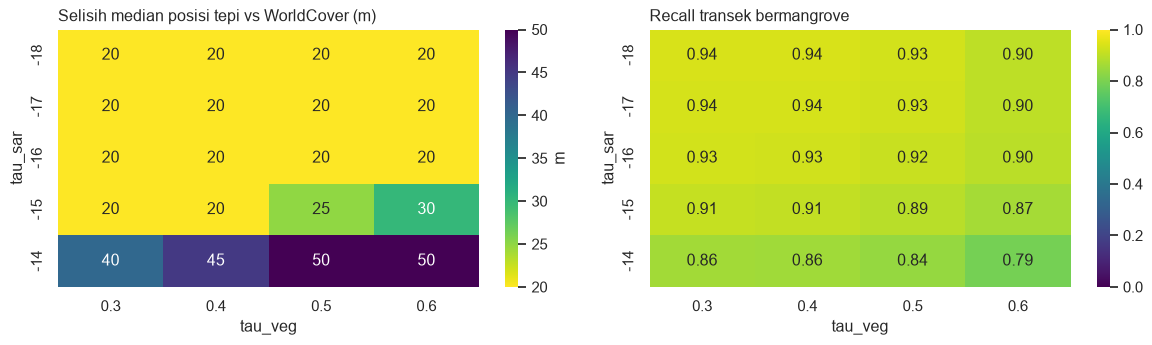

,tau_veg,tau_sar,syarat_tambahan,transek_terdeteksi,presisi,recall,F1,selisih_median_m,bias_m
versi,,,,,,,,,
panduan (−14 dB),0.4,-14,False,1747,0.364,0.901,0.519,40.0,20.0
panduan (−14 dB),0.4,-14,True,1329,0.455,0.857,0.595,45.0,30.0
dipakai,0.4,-16,False,2064,0.333,0.975,0.497,20.0,0.0
dipakai,0.4,-16,True,1585,0.413,0.928,0.572,20.0,10.0


In [11]:
piv = kal[kal.syarat_tambahan].pivot(index="tau_sar", columns="tau_veg", values="selisih_median_m")
piv2 = kal[kal.syarat_tambahan].pivot(index="tau_sar", columns="tau_veg", values="recall")
fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
sns.heatmap(piv, annot=True, fmt=".0f", cmap="viridis_r", ax=ax[0], cbar_kws=dict(label="m"))
ax[0].set_title("Selisih median posisi tepi vs WorldCover (m)", loc="left")
sns.heatmap(piv2, annot=True, fmt=".2f", cmap="viridis", ax=ax[1], vmin=0, vmax=1)
ax[1].set_title("Recall transek bermangrove", loc="left")
plt.tight_layout(); simpan("03_kalibrasi_ambang"); plt.show()
pilih = kal[(kal.tau_veg == PARAM["TAU_VEG"]) & (kal.tau_sar == PARAM["TAU_SAR"])]
panduan = kal[(kal.tau_veg == 0.4) & (kal.tau_sar == -14)]
pd.concat([panduan.assign(versi="panduan (−14 dB)"), pilih.assign(versi="dipakai")]).set_index("versi").round(3)

**Keputusan kalibrasi.** Dengan syarat tambahan (kelas DW + hijau sepanjang tahun) dan τ_veg = 0,4:

| τ_SAR | recall | presisi | selisih posisi median |
|---|---|---|---|
| −14 dB (panduan) | 0,86 | 0,46 | 45 m |
| **−16 dB (dipakai)** | **0,93** | 0,41 | **20 m** |
| −17 / −18 dB | 0,94 | 0,40 | 20 m |

- **Posisi tepi** paling akurat mulai −16 dB (±2 piksel); menurunkan ambang lebih jauh tidak menambah akurasi.
- **Presisi keberadaan** tetap ≤ 0,46 di semua kombinasi: NDVI + VH juga menangkap pohon dan sawah pesisir.

Karena itu **keberadaan** mangrove ditentukan WorldCover 2021 (Bagian 3.2), sedangkan **posisi dan dinamika**
bulanan dari Sentinel-1/2 dengan τ_veg = 0,4 dan τ_SAR = −16 dB.

### 3.2 Domain mangrove (masalah M4, M5)

Transek masuk domain bila WorldCover 2021 memuat rangkaian mangrove ≥ 30 m dalam 0–1.500 m. Pencarian tepi
dibatasi sampai 100 m di belakang ujung darat sabuk mangrove WorldCover, supaya tepi tidak "melompat" ke
pohon permukiman bila tegakan depan hilang (bulan seperti itu menjadi kosong, bukan tepi palsu).

In [12]:
DOM = WC_ADA.copy()
wc_akhir = np.array([DIST[: JMAX + 50][WC[i, : JMAX + 50] == 95].max() if DOM[i] else np.nan for i in range(N)])
BATAS = np.where(DOM, wc_akhir + 100, np.nan)
iD = np.flatnonzero(DOM); ND = len(iD)
dom_tab = pd.DataFrame({"transek": pd.Series(REG_I).value_counts(), "domain_mangrove": pd.Series(REG_I[DOM]).value_counts()}).reindex(REG)
dom_tab["proporsi"] = dom_tab.domain_mangrove / dom_tab.transek
dom_tab.loc["TOTAL"] = [N, ND, ND / N]
print(f"Domain mangrove: {ND} transek; observasi transek-bulan = {ND * T:,}")
tabel(dom_tab.round(3), "03_domain_mangrove")

Domain mangrove: 706 transek; observasi transek-bulan = 48,008


,transek,domain_mangrove,proporsi
PKL,290.0,17.0,0.059
SEM,315.0,107.0,0.340
CIR,405.0,40.0,0.099
SBY,1165.0,538.0,0.462
JPR,190.0,4.0,0.021
TOTAL,2365.0,706.0,0.299


### 3.3 Tepi mangrove bulanan $Y_{i,t}$

$Y_{i,t}$ = `dist_m` titik pertama dari laut yang mengawali ≥ 3 titik berturut-turut dengan
NDVI > τ_veg, VH > τ_SAR, kelas DW tahunan pohon/vegetasi tergenang, dan hijau sepanjang tahun. Nilai **naik =
tepi mundur ke darat**. Pencilan akibat awan/lintasan dibuang dengan filter Hampel (jendela 7 bulan, 3 MAD).

Fraksi bulan dengan Y terukur: 0.57 -> 0.55 setelah buang pencilan (1,068 pencilan)


,terdeteksi,setelah_Hampel
reg,,
PKL,0.27,0.25
SEM,0.58,0.55
CIR,0.68,0.64
SBY,0.56,0.54
JPR,0.76,0.67


Validasi tepi 2021 vs WorldCover (domain): selisih median |ΔY| = 20 m, bias = +10 m, korelasi Spearman = 0.69


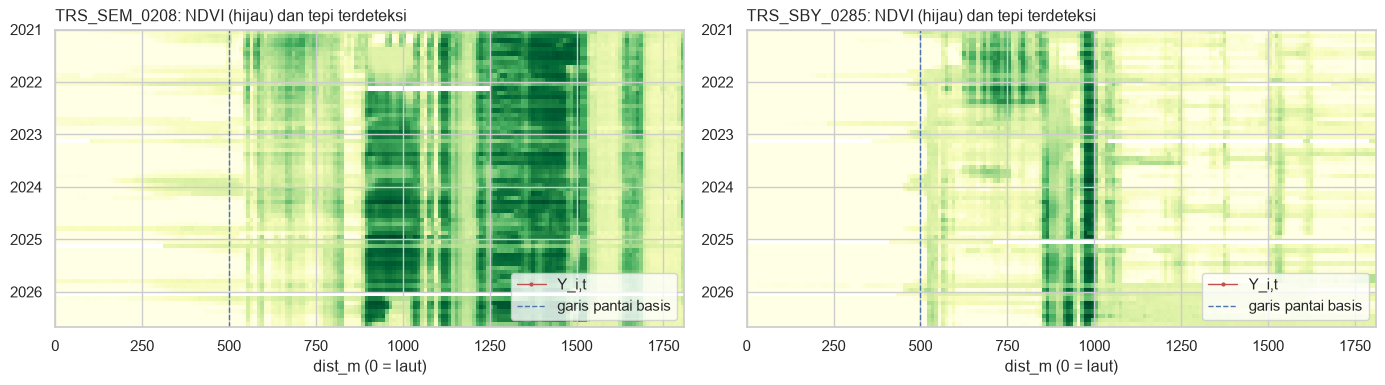

In [13]:
Y_raw = deteksi_tepi(PARAM["TAU_VEG"], PARAM["TAU_SAR"], batas=BATAS[iD], iset=iD)

def hampel(Y, w=7, k=3.0):
    df = pd.DataFrame(Y.T)
    med = df.rolling(w, center=True, min_periods=3).median()
    mad = (df - med).abs().rolling(w, center=True, min_periods=3).median() * 1.4826
    out = (df - med).abs() > k * mad.clip(lower=STEP)
    Y2 = Y.copy(); Y2[out.T.to_numpy()] = np.nan
    return Y2, out.to_numpy().T

Y, PENCILAN = hampel(Y_raw)
REG_D = REG_I[iD]
ob = pd.DataFrame({"terdeteksi": np.isfinite(Y_raw).mean(1), "setelah_Hampel": np.isfinite(Y).mean(1), "reg": REG_D})
print(f"Fraksi bulan dengan Y terukur: {np.isfinite(Y_raw).mean():.2f} -> {np.isfinite(Y).mean():.2f} setelah buang pencilan "
      f"({PENCILAN.sum():,} pencilan)")
display(ob.groupby("reg").mean().reindex(REG).round(2))
Y21 = np.nanmedian(Y[:, TH_T == 2021], 1); b = np.isfinite(Y21)
print(f"Validasi tepi 2021 vs WorldCover (domain): selisih median |ΔY| = {np.nanmedian(np.abs(Y21[b] - WC_Y[iD][b])):.0f} m, "
      f"bias = {np.nanmedian(Y21[b] - WC_Y[iD][b]):+.0f} m, korelasi Spearman = {spearmanr(Y21[b], WC_Y[iD][b])[0]:.2f}")

# contoh transek: profil NDVI sepanjang waktu + tepi terdeteksi
contoh = [iD[np.argmax(np.where(REG_D == r, np.nanstd(Y, 1), -1))] for r in ["SEM", "SBY"]]
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
for a, i in zip(ax, contoh):
    k = np.flatnonzero(iD == i)[0]
    a.imshow(NDVI[i, :JMAX + 30].T, aspect="auto", cmap="YlGn", vmin=-0.2, vmax=0.9,
             extent=[0, (JMAX + 30) * STEP, T, 0])
    a.plot(Y[k], np.arange(T) + 0.5, "r.-", lw=1, ms=4, label="Y_i,t")
    a.axvline(LEN_SEA, c="b", ls="--", lw=1, label="garis pantai basis")
    a.set_title(f"{IDS[i]}: NDVI (hijau) dan tepi terdeteksi", loc="left"); a.set_xlabel("dist_m (0 = laut)")
    a.set_yticks(np.arange(0, T, 12)); a.set_yticklabels(TAHUN); a.legend(loc="lower right")
plt.tight_layout(); simpan("03_contoh_tepi"); plt.show()

**Interpretasi.** Domain mangrove = **706 transek** (30%): SBY 538, SEM 107, CIR 40, PKL 17, JPR 4. Dari 48.008
transek-bulan, $Y_{i,t}$ terukur pada 55%; paling rendah di PKL (25%) karena celah VH dan awan musim hujan.
Tepi 2021 hasil Sentinel-1/2 berselisih median **20 m** (bias +10 m, ρ = 0,69) dari tepi WorldCover yang dibuat
dengan metode lain, sehingga $Y_{i,t}$ cukup akurat untuk dipakai sebagai respons model.

JPR hanya punya 4 transek domain, sehingga **Jepara tidak bisa berfungsi sebagai kontrol wilayah** untuk laju
tepi (masalah M5). Peran kontrol digantikan variasi kovariat kontinu antar-transek di Bagian 5.

### 3.4 Penghalang keras $B^{hard}_{i,t}$ (masalah M8)

Penghalang keras tahun $y$ = titik darat pertama **di belakang tepi mangrove** yang berupa:
(a) ≥ 2 titik berturut-turut dengan P(built) Dynamic World > τ_built, atau (b) persilangan jalan/rel/tanggul/tol
(OSM, termasuk ruas yang sedang dibangun) dan struktur baru terdeteksi DW dengan `tahun_mulai` ≤ $y$.
Transek tanpa penghalang sampai ujung darat ditandai **tersensor** ($B$ = 3.500 m sebagai batas bawah).

In [14]:
idx_i = {t: k for k, t in enumerate(IDS)}
BAR["i"] = BAR.transek_id.map(idx_i); BAR["j"] = np.clip(np.round(BAR.dist_m / STEP).astype(int), 0, P - 1)
BAR["tahun"] = BAR.tahun_mulai.fillna(2021).astype(int)

def penghalang_keras(tau_built, Yref):
    # Yref [N_dom, tahun]: posisi tepi acuan per tahun. Hasil B [N_dom, tahun], tersensor [N_dom, tahun]
    B = np.full((ND, len(TAHUN)), np.nan); sens = np.zeros_like(B, bool)
    for a, y in enumerate(TAHUN):
        H = DW[iD, :, a, 3] > tau_built
        H = H & np.concatenate([H[:, 1:], np.zeros((ND, 1), bool)], 1) if PARAM["BUILT_RUN"] == 2 else H
        br = BAR[(BAR.tahun <= y) & BAR.i.isin(iD)]
        kD = np.searchsorted(iD, br.i.to_numpy())
        H[kD, br.j.to_numpy()] = True
        H &= DIST[None, :] > np.nan_to_num(Yref[:, a], nan=LEN_SEA)[:, None]
        ada = H.any(1)
        B[:, a] = np.where(ada, H.argmax(1) * STEP, DIST[-1]); sens[:, a] = ~ada
    return B, sens

YREF = np.stack([np.nanmedian(Y[:, TH_T == y], 1) for y in TAHUN], 1)
YREF = pd.DataFrame(YREF).ffill(axis=1).bfill(axis=1).fillna(LEN_SEA).to_numpy()
B_HARD, B_SENS = penghalang_keras(PARAM["TAU_BUILT"], YREF)
bh = pd.DataFrame({"reg": REG_D, "B_2021": B_HARD[:, 0], "B_2026": B_HARD[:, -1], "tersensor": B_SENS[:, -1],
                   "maju_ke_laut_m": B_HARD[:, 0] - B_HARD[:, -1]})
display(bh.groupby("reg").agg(B_median_2026=("B_2026", "median"), tersensor=("tersensor", "mean"),
                              transek_penghalang_maju=("maju_ke_laut_m", lambda s: (s > 0).mean()),
                              maju_median_bila_maju_m=("maju_ke_laut_m", lambda s: s[s > 0].median())).reindex(REG).round(2))

,B_median_2026,tersensor,transek_penghalang_maju,maju_median_bila_maju_m
reg,,,,
PKL,3060.0,0.18,0.24,100.0
SEM,3500.0,0.60,0.16,10.0
CIR,3500.0,0.68,0.10,50.0
SBY,2540.0,0.41,0.23,25.0
JPR,3500.0,1.00,0.00,NaN


**Interpretasi.** Penghalang keras paling dekat di **SBY** (median 2,5 km di belakang garis pantai) dan **PKL**
(3,1 km). Di SEM, CIR, dan JPR sebagian besar transek **tersensor** (60%, 68%, 100%): tidak ada struktur keras
sampai 3 km ke darat, sehingga $MS_i$ di sana adalah **batas bawah** dan peluang tertutup di Bagian 6 cenderung
terlalu kecil. Perubahan posisi penghalang 2021→2026 dibahas di Bagian 6.

### 3.5 Penghalang lunak, jendela hidroperiode, dan ruang peluang

**[Penyesuaian]** Panduan memakai elevasi 0,5–2,0 m, tetapi GLO-30 meratakan tambak (±0 m) dan mendahului amblesan.
Kesesuaian diganti **jendela hidroperiode**: sebaran frekuensi genangan `inund_freq` pada **dataran pasang-surut**
0–50 m di depan tepi mangrove pada transek yang stabil (|laju| < 5 m/th), persentil 5–95. Dataran pasang-surut
= titik yang genangannya mengikuti pasang (`tide_coupling` > 0,05); tanpa syarat ini, titik yang tidak pernah
tergenang ikut terhitung dan batas bawah jendela menjadi 0 (semua lahan kering dianggap sesuai).

- $B^{soft}_i$ = titik pertama di belakang tepi berkelas DW 2026 air/lahan terbuka (tambak, lahan kosong);
- $Space_{opp,i} = B^{hard}_i - B^{soft}_i$ (0 bila tidak ada lahan lunak);
- HydroSuitability$_i$ = fraksi titik di $[B^{soft}_i, B^{hard}_i)$ yang genangannya di dalam jendela.

Jendela hidroperiode (P5–P95 genangan dataran pasang-surut 0–50 m di depan tepi, 333 transek stabil, 709 titik): 0.04 – 0.76
tide_coupling median: dataran di depan tepi 0.11 vs lahan air/terbuka di belakang tepi 0.01 (tambak tertutup pematang tidak mengikuti pasang)
Ruang peluang > 0 pada 83% transek domain; median 2310 m; HydroSuitability median 0.44


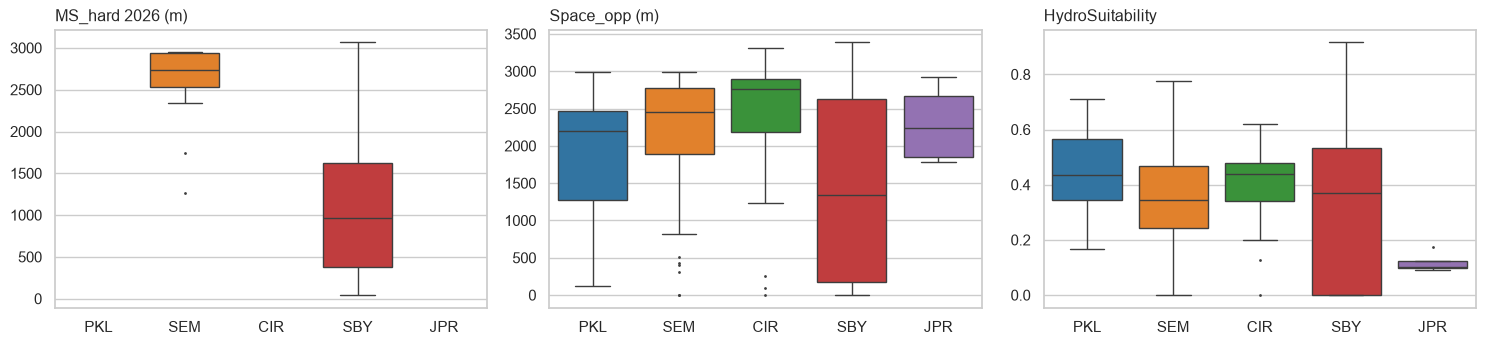

In [15]:
dom26 = DW[:, :, 5, :].argmax(-1)                       # kelas dominan 2026 [N,P]
Y_lr = np.array([np.polyfit(np.flatnonzero(np.isfinite(y)) / 12, y[np.isfinite(y)], 1)[0] if np.isfinite(y).sum() > 24 else np.nan for y in Y])
stabil = np.abs(Y_lr) < 5
depan = []
for k in np.flatnonzero(stabil):
    i = iD[k]; y0 = YREF[k, -1]
    j = (DIST >= y0 - 50) & (DIST < y0) & (TIDEC[i] > 0.05)
    depan.append(INUND[i, j])
depan = np.concatenate(depan); depan = depan[np.isfinite(depan)]
JENDELA = tuple(np.quantile(depan, [0.05, 0.95]))
print(f"Jendela hidroperiode (P5–P95 genangan dataran pasang-surut 0–50 m di depan tepi, {stabil.sum()} transek stabil, "
      f"{depan.size} titik): {JENDELA[0]:.2f} – {JENDELA[1]:.2f}")
print(f"tide_coupling median: dataran di depan tepi {np.nanmedian(np.concatenate([TIDEC[iD[k], (DIST >= YREF[k, -1] - 100) & (DIST < YREF[k, -1])] for k in range(ND)])):.2f} "
      f"vs lahan air/terbuka di belakang tepi {np.nanmedian(np.concatenate([TIDEC[iD[k], (DIST > YREF[k, -1]) & np.isin(dom26[iD[k]], [0, 4])] for k in range(ND)])):.2f} "
      "(tambak tertutup pematang tidak mengikuti pasang)")

def ruang_peluang(Yref_akhir, Bh_akhir, iset):
    B_soft = np.full(len(iset), np.nan); opp = np.zeros(len(iset)); hyd = np.zeros(len(iset))
    for k, i in enumerate(iset):
        zona = (DIST > Yref_akhir[k]) & (DIST < Bh_akhir[k])
        lunak = zona & np.isin(dom26[i], [0, 4])
        if lunak.any():
            j0 = np.flatnonzero(lunak)[0]
            B_soft[k] = DIST[j0]; opp[k] = Bh_akhir[k] - DIST[j0]
            seg = (DIST >= DIST[j0]) & (DIST < Bh_akhir[k])
            hyd[k] = np.mean((INUND[i, seg] >= JENDELA[0]) & (INUND[i, seg] <= JENDELA[1]))
    return B_soft, opp, hyd

B_SOFT, OPP, HYD = ruang_peluang(YREF[:, -1], B_HARD[:, -1], iD)
MS_BULAN = B_HARD[:, TH_T - 2021] - Y                  # [ND, T]
print(f"Ruang peluang > 0 pada {np.mean(OPP > 0):.0%} transek domain; median {np.median(OPP[OPP > 0]):.0f} m; "
      f"HydroSuitability median {np.median(HYD[OPP > 0]):.2f}")
fig, ax = plt.subplots(1, 3, figsize=(15, 3.6))
for a, v, jud in [(ax[0], MS_BULAN[:, -12:].mean(1), "MS_hard 2026 (m)"), (ax[1], OPP, "Space_opp (m)"), (ax[2], HYD, "HydroSuitability")]:
    sns.boxplot(x=REG_D, y=v, order=REG, ax=a, palette=REG_WARNA, fliersize=1); a.set_title(jud, loc="left")
plt.tight_layout(); simpan("03_ms_opp_hyd"); plt.show()

**Interpretasi.** Jendela hidroperiode = genangan **0,04–0,76** (dataran pasang-surut tergenang 4–76% akuisisi).
Tambak di belakang tepi hampir tidak mengikuti pasang (`tide_coupling` median 0,01 vs 0,11 di dataran lumpur): air
tambak dikendalikan pematang, bukan pasang. Ruang peluang ada di 83% transek domain (median 2,3 km), dan pada transek
median **44% titik ruang peluang** sudah berada di dalam jendela hidroperiode. Artinya, bila pematang dibuka, sebagian besar lahan
tambak itu berada pada frekuensi genangan yang cocok untuk mangrove perintis. Ini dasar tipologi *managed
realignment* di Bagian 7.

## 4. Nowcast dan forecast tepi mangrove

Model utama adalah **state-space local linear trend** per transek (panduan 5.2):

$$y_{i,t} = \mu_{i,t} + \varepsilon_{i,t},\quad \mu_{i,t} = \mu_{i,t-1} + \beta_{i,t-1} + \eta_{i,t},\quad \beta_{i,t} = \beta_{i,t-1} + \zeta_{i,t}$$

$y_{i,t}$ = $Y_{i,t}$ (m), $\mu$ = posisi tepi "sebenarnya", $\beta$ = laju (m/bulan, + = mundur ke darat).
Bulan kosong (masalah M1, M2) tidak diisi: Kalman hanya melakukan langkah prediksi, sehingga varians posterior
membesar secara jujur di celah data. Varians $(\sigma_\varepsilon, \sigma_\eta, \sigma_\zeta)$ diestimasi dengan
*maximum likelihood* per wilayah (wilayah dengan < 20 transek domain memakai parameter gabungan).

**[Penyesuaian]** 1 langkah = 1 bulan (bukan 15 hari), sehingga horizon 6 dan 12 bulan = 6 dan 12 langkah.

In [16]:
F = np.array([[1.0, 1.0], [0.0, 1.0]])

def kalman(Yn, s_eps, s_eta, s_zeta):
    n = Yn.shape[0]; R = s_eps ** 2; Q = np.diag([s_eta ** 2, s_zeta ** 2])
    first = np.array([y[np.isfinite(y)][0] if np.isfinite(y).any() else LEN_SEA for y in Yn])
    x = np.stack([first, np.zeros(n)], 1); Pm = np.tile(np.diag([R + 50.0 ** 2, 2.0 ** 2]), (n, 1, 1))
    ll = np.zeros(n); X = np.zeros((n, T, 2)); PP = np.zeros((n, T, 2, 2))
    for t in range(Yn.shape[1]):
        if t > 0:
            x = x @ F.T; Pm = F @ Pm @ F.T + Q
        y = Yn[:, t]; o = np.isfinite(y)
        v = np.where(o, y - x[:, 0], 0.0); S = Pm[:, 0, 0] + R
        K = Pm[:, :, 0] / S[:, None]
        x = x + K * (v * o)[:, None]
        Pm = Pm - o[:, None, None] * K[:, :, None] * Pm[:, None, 0, :]
        ll += np.where(o, -0.5 * (np.log(2 * np.pi * S) + v ** 2 / S), 0.0)
        X[:, t] = x; PP[:, t] = Pm
    return ll, X[:, : Yn.shape[1]], PP[:, : Yn.shape[1]]

def fit_param(Yn):
    f = lambda th: -kalman(Yn, *np.exp(th))[0].sum()
    r = optimize.minimize(f, np.log([30.0, 3.0, 0.3]), method="Nelder-Mead", options=dict(maxiter=600, xatol=1e-3, fatol=1e-2))
    return np.exp(r.x)

def param_wilayah(Yn, reg_arr):
    gab = fit_param(Yn)
    return {r: (fit_param(Yn[reg_arr == r]) if (reg_arr == r).sum() >= 20 else gab) for r in REG} | {"GABUNGAN": gab}

def filter_semua(Yn, reg_arr, par):
    X = np.zeros((len(Yn), Yn.shape[1], 2)); PP = np.zeros((len(Yn), Yn.shape[1], 2, 2))
    for r in REG:
        m = reg_arr == r
        if m.any():
            _, X[m], PP[m] = kalman(Yn[m], *par[r])
    return X, PP

def ramal(x, Pm, k, par_baris):
    # x [n,2], Pm [n,2,2], par_baris [n,3]; hasil mean dan varians observasi k langkah ke depan
    Fk = np.linalg.matrix_power(F, k)
    m = x @ Fk.T
    V = Fk @ Pm @ Fk.T
    for j in range(k):
        Fj = np.linalg.matrix_power(F, j)
        V = V + np.einsum("ab,nbc,dc->nad", Fj, np.stack([np.diag([a ** 2, b ** 2]) for a, b in par_baris[:, 1:]]), Fj)
    return m[:, 0], V[:, 0, 0] + par_baris[:, 0] ** 2, V

t0 = time.time()
PAR_BT = param_wilayah(Y[:, : T0_BACKTEST + 1], REG_D)
PAR = param_wilayah(Y, REG_D)
ptab = pd.DataFrame(PAR, index=["σ_ε (m)", "σ_η (m/bln)", "σ_ζ (m/bln²)"]).T
print(f"estimasi parameter {time.time() - t0:.0f} s"); ptab.round(3)

estimasi parameter 49 s


,σ_ε (m),σ_η (m/bln),σ_ζ (m/bln²)
PKL,25.670,25.792,0.000
SEM,36.020,32.850,0.168
CIR,8.329,27.248,0.000
SBY,22.094,22.232,0.000
JPR,25.670,25.792,0.000
GABUNGAN,25.670,25.792,0.000


### 4.1 Backtest rolling-origin

Parameter diestimasi hanya dari data ≤ Agustus 2023. Origin digeser per bulan dari Agustus 2023, dan ramalan
$t+6$ dan $t+12$ dibandingkan dengan $Y$ teramati. Pembanding:

- **Persistensi**: nilai teramati terakhir;
- **OLS drift** (panduan Model A): garis lurus 24 bulan terakhir;
- **Gradient boosting** (panduan Model B): memprediksi perubahan posisi dari fitur riwayat 12 bulan dan kovariat
  tekanan, dilatih hanya pada origin yang targetnya ≤ Agustus 2023 (tanpa kebocoran waktu).

Ukuran: RMSE, MAE, CRPS (untuk ramalan probabilistik; model non-Kalman memakai sebaran Gauss dengan simpangan
dari galat latihnya), dan cakupan interval 95%.

In [17]:
par_bt = np.array([PAR_BT[r] for r in REG_D])
X_bt, P_bt = filter_semua(Y, REG_D, PAR_BT)
Yffill = pd.DataFrame(Y.T).ffill().to_numpy().T                     # persistensi

def ols_drift(o, h, w=24):
    tt = np.arange(max(0, o - w + 1), o + 1); Yw = Y[:, tt]; m = np.isfinite(Yw)
    n = m.sum(1); tx = np.where(m, tt, 0); ty = np.where(m, Yw, 0)
    sx, sy, sxx, sxy = tx.sum(1), ty.sum(1), (tx ** 2).sum(1), (tx * ty).sum(1)
    b = (n * sxy - sx * sy) / np.where(n * sxx - sx ** 2 == 0, np.nan, n * sxx - sx ** 2)
    a = (sy - b * sx) / np.where(n == 0, np.nan, n)
    return np.where(n >= 6, a + b * (o + h), np.nan), b

subs_i = TR.subs_rate.to_numpy()[iD]
def fitur(o):
    # fitur riwayat 12 bulan terakhir (origin paling awal = bulan ke-12)
    _, b12 = ols_drift(o, 0, w=12)
    return np.column_stack([Yffill[:, o], np.nanmean(Y[:, o - 5 : o + 1], 1), b12, np.isfinite(Y[:, o - 11 : o + 1]).sum(1),
                            subs_i, TR.inund_darat.to_numpy()[iD], TR.built_2026_darat.to_numpy()[iD],
                            pd.Categorical(REG_D, categories=REG).codes])

def crps_gauss(y, mu, s):
    z = (y - mu) / s
    return s * (z * (2 * norm.cdf(z) - 1) + 2 * norm.pdf(z) - 1 / np.sqrt(np.pi))

bt = []
for h in [6, 12]:
    o_lat = range(11, T0_BACKTEST - h + 1); o_uji = range(T0_BACKTEST, T - h)   # target latih <= Agustus 2023
    Xl = np.vstack([fitur(o) for o in o_lat]); yl = np.concatenate([Y[:, o + h] - Yffill[:, o] for o in o_lat])
    ml = np.isfinite(yl) & np.isfinite(Xl[:, 0])
    gbm = HistGradientBoostingRegressor(max_iter=300, learning_rate=0.05, max_leaf_nodes=15, random_state=0).fit(Xl[ml], yl[ml])
    # simpangan baku galat latih untuk model non-Kalman
    s_lat = {}
    res_p = np.concatenate([Y[:, o + h] - Yffill[:, o] for o in o_lat]); s_lat["Persistensi"] = np.nanstd(res_p)
    res_o = np.concatenate([Y[:, o + h] - ols_drift(o, h)[0] for o in o_lat]); s_lat["OLS drift"] = np.nanstd(res_o)
    s_lat["Gradient boosting"] = np.nanstd(yl[ml] - gbm.predict(Xl[ml]))
    for o in o_uji:
        obs = Y[:, o + h]
        mu_k, var_k, _ = ramal(X_bt[:, o], P_bt[:, o], h, par_bt)
        pred = {"Kalman LLT": (mu_k, np.sqrt(var_k)), "Persistensi": (Yffill[:, o], None),
                "OLS drift": (ols_drift(o, h)[0], None), "Gradient boosting": (Yffill[:, o] + gbm.predict(fitur(o)), None)}
        for nama, (mu, s) in pred.items():
            s = np.full(len(obs), s_lat[nama]) if s is None else s
            m = np.isfinite(obs) & np.isfinite(mu)
            bt.append(pd.DataFrame(dict(model=nama, h=h, origin=o, reg=REG_D[m], err=obs[m] - mu[m],
                                        crps=crps_gauss(obs[m], mu[m], s[m]), cov=np.abs(obs[m] - mu[m]) <= 1.96 * s[m])))
bt = pd.concat(bt, ignore_index=True)
skor = bt.groupby(["h", "model"]).agg(n=("err", "size"), RMSE=("err", lambda e: np.sqrt(np.mean(e ** 2))),
                                      MAE=("err", lambda e: np.mean(np.abs(e))), CRPS=("crps", "mean"), cakupan95=("cov", "mean"))
tabel(skor.round(2), "04_backtest_skor")

n    RMSE    MAE   CRPS  cakupan95
h  model                                                    
6  Gradient boosting  12848   75.79  33.75  28.96       0.93
   Kalman LLT         12889   74.66  23.33  29.74       0.97
   OLS drift          12546   88.02  29.75  39.17       0.97
   Persistensi        12848   72.82  21.31  30.45       0.98
12 Gradient boosting  10300   96.53  51.56  42.78       0.83
   Kalman LLT         10348   85.61  29.01  37.55       0.98
   OLS drift           9986  116.24  41.42  55.77       0.97
   Persistensi        10300   78.88  25.27  36.67       0.98

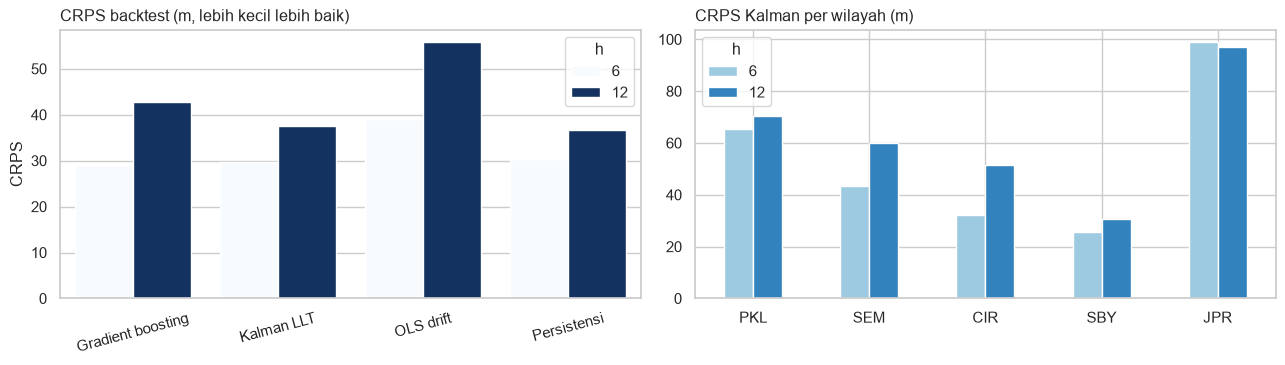

In [18]:
fig, ax = plt.subplots(1, 2, figsize=(13, 3.8))
sk = skor.reset_index()
sns.barplot(sk, x="model", y="CRPS", hue="h", ax=ax[0], palette="Blues"); ax[0].set_title("CRPS backtest (m, lebih kecil lebih baik)", loc="left")
ax[0].tick_params(axis="x", rotation=15); ax[0].set_xlabel("")
kr = bt[bt.model == "Kalman LLT"].groupby(["reg", "h"]).crps.mean().unstack().reindex(REG)
kr.plot.bar(ax=ax[1], rot=0, color=["#9ecae1", "#3182bd"]); ax[1].set_title("CRPS Kalman per wilayah (m)", loc="left"); ax[1].set_xlabel("")
plt.tight_layout(); simpan("04_backtest"); plt.show()

**Interpretasi.**

- **Dalam 6–12 bulan, tepi mangrove hampir diam.** Persistensi (nilai terakhir) punya MAE terkecil (21 m untuk t+6,
  25 m untuk t+12). OLS drift paling buruk (CRPS 39–56 m) karena mengekstrapolasi derau sebagai tren.
- **Kalman setara persistensi dalam akurasi titik** (CRPS 29,7 vs 30,5 m untuk t+6; 37,5 vs 36,7 m untuk t+12),
  tetapi **ketidakpastiannya terkalibrasi** (cakupan interval 95% = 97–98%). Nilai tambah Kalman bukan menebak
  posisi lebih tepat, tetapi memberi laju $v_i$ dan simpangan $\sigma$ yang jujur, yang dipakai untuk
  $P(\text{Closed})$ di Bagian 6.
- Gradient boosting sedikit lebih baik untuk CRPS t+6 (29,0 m) tetapi cakupannya kurang (93% untuk t+6, 83% untuk
  t+12): intervalnya terlalu sempit untuk dipakai sebagai dasar peluang.
- Galat terbesar di PKL dan JPR (CRPS 65–99 m), yaitu wilayah dengan paling sedikit transek dan bulan terukur.

Estimasi varians menunjukkan $\sigma_\zeta \approx 0$: laju tiap transek praktis **konstan** selama 2021–2026, dan
variasi bulan ke bulan diserap oleh level ($\sigma_\eta$ 22–33 m/bulan) dan galat observasi.

### 4.2 Nowcast Agustus 2026 dan forecast 6–12 bulan

Model akhir memakai parameter dari seluruh data. Keluaran per transek: posisi tepi $\hat\mu_{i,T}$ dan
simpangannya, laju $v_i = 12\hat\beta_{i,T}$ (m/tahun, + = mundur ke darat) beserta $\sigma_{v,i}$, dan ramalan
posisi Februari 2027 (t+6) dan Agustus 2027 (t+12) dengan pita 95%.

,transek,v_median,v_sd_median,mundur_sig,maju_sig
reg,,,,,
PKL,17,0.00,21.81,0.00,0.00
SEM,107,0.36,26.07,0.00,0.00
CIR,40,-0.23,20.63,0.00,0.02
SBY,538,-0.06,19.39,0.01,0.01
JPR,4,-2.75,20.36,0.00,0.00


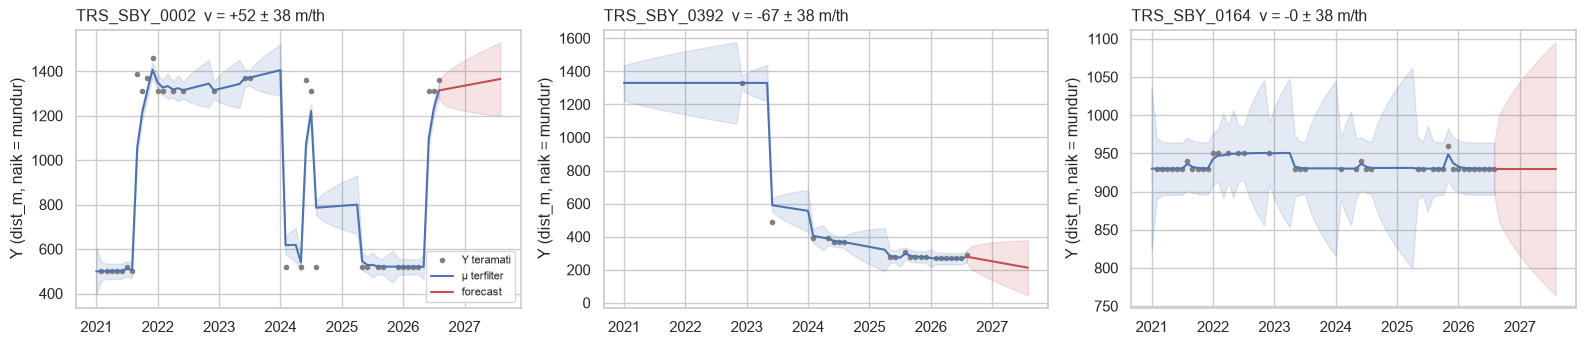

In [19]:
par_i = np.array([PAR[r] for r in REG_D])
X_kf, P_kf = filter_semua(Y, REG_D, PAR)
MU_T, SD_MU = X_kf[:, -1, 0], np.sqrt(P_kf[:, -1, 0, 0])
V_KF, SD_V = 12 * X_kf[:, -1, 1], 12 * np.sqrt(P_kf[:, -1, 1, 1])
FC = {}
for k in [6, 12]:
    m_, v_, _ = ramal(X_kf[:, -1], P_kf[:, -1], k, par_i); FC[k] = (m_, np.sqrt(v_))
NOW = pd.DataFrame({"transek_id": IDS[iD], "reg": REG_D, "Y_now": MU_T, "Y_sd": SD_MU, "v_kf": V_KF, "v_sd": SD_V,
                    "Y_t6": FC[6][0], "Y_t6_sd": FC[6][1], "Y_t12": FC[12][0], "Y_t12_sd": FC[12][1]})
NOW["mundur_signifikan"] = (NOW.v_kf - 1.96 * NOW.v_sd) > 0
NOW["maju_signifikan"] = (NOW.v_kf + 1.96 * NOW.v_sd) < 0
display(NOW.groupby("reg").agg(transek=("v_kf", "size"), v_median=("v_kf", "median"), v_sd_median=("v_sd", "median"),
                               mundur_sig=("mundur_signifikan", "mean"), maju_sig=("maju_signifikan", "mean")).reindex(REG).round(2))

pilih_ = [int(NOW.v_kf.idxmax()), int(NOW.v_kf.idxmin()), int((NOW.v_kf - NOW.v_kf.median()).abs().idxmin())]
fig, ax = plt.subplots(1, 3, figsize=(16, 3.6), sharey=False)
tt = np.arange(T); tf = np.arange(T - 1, T + 12)
for a, k in zip(ax, pilih_):
    a.plot(tt, Y[k], "o", ms=3, c="grey", label="Y teramati")
    a.plot(tt, X_kf[k, :, 0], c="C0", label="μ terfilter")
    sd = np.sqrt(P_kf[k, :, 0, 0]); a.fill_between(tt, X_kf[k, :, 0] - 1.96 * sd, X_kf[k, :, 0] + 1.96 * sd, color="C0", alpha=0.15)
    mu_f = [MU_T[k]] + [ramal(X_kf[[k], -1], P_kf[[k], -1], h, par_i[[k]])[0][0] for h in range(1, 13)]
    sd_f = [SD_MU[k]] + [np.sqrt(ramal(X_kf[[k], -1], P_kf[[k], -1], h, par_i[[k]])[1][0]) for h in range(1, 13)]
    a.plot(tf, mu_f, c="C3", label="forecast"); a.fill_between(tf, np.array(mu_f) - 1.96 * np.array(sd_f), np.array(mu_f) + 1.96 * np.array(sd_f), color="C3", alpha=0.15)
    a.set_title(f"{NOW.transek_id[k]}  v = {V_KF[k]:+.0f} ± {1.96 * SD_V[k]:.0f} m/th", loc="left")
    a.set_xticks(np.arange(0, T + 12, 12)); a.set_xticklabels(list(TAHUN) + [2027]); a.set_ylabel("Y (dist_m, naik = mundur)")
ax[0].legend(fontsize=8); plt.tight_layout(); simpan("04_nowcast_forecast"); plt.show()

**Interpretasi.** Median laju tepi hasil Kalman mendekati nol di semua wilayah (SEM +0,4, CIR −0,2, SBY −0,1 m/th),
dengan simpangan per transek ±19–26 m/th. Hampir tidak ada transek yang laju individunya signifikan. Artinya,
**satu transek saja tidak cukup untuk memastikan mundur atau maju** dalam 5,7 tahun data; sinyal tekanan harus
dicari pada **populasi transek**, yaitu tujuan Bagian 5.

## 5. Laju mundur dan dekomposisi dua tekanan

Pertanyaan: **seberapa besar laju mundur tepi dijelaskan tekanan sisi laut dan sisi darat?** (panduan 5.3)

$$v_i = \gamma_0 + \underbrace{\gamma_1 Subs_i + \gamma_2 Inund_i}_{\text{sisi laut}} + \underbrace{\gamma_3 BuiltDensity_i}_{\text{sisi darat}} + u_i$$

- Respons: laju jangka panjang $v^{lr}_i$ = kemiringan OLS $Y_{i,t}$ 2021–2026 (m/th). Laju Kalman $v_i$ di Bagian 4
  menggambarkan kondisi terkini dan dipakai untuk peluang di Bagian 6; laju jangka panjang lebih cocok untuk
  menghubungkan tekanan yang bersifat persisten.
- $Subs_i$: laju amblesan InSAR (cm/th, + = turun); transek kosong (M6) diisi median transek domain dalam 1 km, ditandai.
- $Inund_i$: frekuensi genangan 0–200 m di belakang tepi; $BuiltDensity_i$: rerata P(built) 2026 0–1 km di belakang tepi.
- Galat baku *cluster-robust* per rangkaian transek bersambung (≤ 1 km), karena transek bertetangga tidak independen.
- Karena $v^{lr}_i$ berekor panjang (deteksi tepi kadang meloncat), model utama adalah **regresi robust Huber**;
  regresi median, OLS cluster, dan OLS + efek tetap wilayah dilaporkan berdampingan. Kesimpulan hanya diambil
  bila arah efek konsisten antarpenduga.

In [20]:
cxy = TR[["cx", "cy"]].to_numpy()[iD]
urut = np.lexsort((IDS[iD], REG_D))
lompat = np.r_[True, (REG_D[urut][1:] != REG_D[urut][:-1]) | (np.hypot(*np.diff(cxy[urut], axis=0).T) > 1000)]
RUN_ID = np.empty(ND, int); RUN_ID[urut] = np.cumsum(lompat)

def isi_subs(v):
    v = v.copy(); kosong = np.isnan(v)
    for k in np.flatnonzero(kosong):
        d = np.hypot(*(cxy - cxy[k]).T); nb = (d <= 1000) & ~kosong
        v[k] = np.median(v[nb]) if nb.any() else np.nan
    reg_med = pd.Series(v).groupby(REG_D).transform("median").to_numpy()
    return np.where(np.isnan(v), reg_med, v), kosong

SUBS, SUBS_IMP = isi_subs(TR.subs_rate.to_numpy()[iD])
yr_idx = np.arange(P)
def rerata_zona(A, y0, lebar):
    m = (DIST[None, :] > y0[:, None]) & (DIST[None, :] <= y0[:, None] + lebar)
    return np.nanmean(np.where(m, A, np.nan), 1)
INUND_I = rerata_zona(INUND[iD], YREF[:, -1], 200)
BUILT_I = rerata_zona(DW[iD, :, 5, 3], YREF[:, -1], 1000)
D5 = pd.DataFrame({"transek_id": IDS[iD], "reg": REG_D, "run": RUN_ID, "v_lr": Y_lr, "v_kf": V_KF,
                   "Subs": SUBS, "Subs_imputasi": SUBS_IMP, "Inund": INUND_I, "BuiltDensity": BUILT_I,
                   "multi_silang": TR.n_silang_pantai.to_numpy()[iD] > 1})
print(f"korelasi Spearman v_lr vs v_kf = {spearmanr(D5.v_lr, D5.v_kf, nan_policy='omit')[0]:.2f}; "
      f"Subs diimputasi pada {SUBS_IMP.mean():.0%} transek")
display(D5.groupby("reg")[["v_lr", "Subs", "Inund", "BuiltDensity"]].median().reindex(REG).round(2))
H = kruskal(*[D5.v_lr[D5.reg == r].dropna() for r in REG if (D5.reg == r).sum() > 3])
print(f"Kruskal–Wallis v_lr antarwilayah: H = {H.statistic:.1f}, p = {H.pvalue:.2g}")

korelasi Spearman v_lr vs v_kf = 0.92; Subs diimputasi pada 24% transek


,v_lr,Subs,Inund,BuiltDensity
reg,,,,
PKL,1.51,6.02,0.06,0.03
SEM,2.80,1.49,0.03,0.03
CIR,-2.21,2.33,0.05,0.03
SBY,-0.91,0.37,0.00,0.04
JPR,-10.96,0.07,0.00,0.04


Kruskal–Wallis v_lr antarwilayah: H = 23.7, p = 9e-05


In [21]:
X5 = ["Subs", "Inund", "BuiltDensity"]
d5 = D5.dropna(subset=["v_lr"] + X5).copy()
z5 = (d5[X5] - d5[X5].mean()) / d5[X5].std()
vif = pd.Series([variance_inflation_factor(sm.add_constant(z5).values, k + 1) for k in range(3)], index=X5, name="VIF")
print(f"Sebaran v_lr: median {d5.v_lr.median():.1f}, IQR {d5.v_lr.quantile(0.25):.1f} s.d. {d5.v_lr.quantile(0.75):.1f}, "
      f"min {d5.v_lr.min():.0f}, maks {d5.v_lr.max():.0f} m/th -> berekor panjang, OLS rentan pencilan")

def ols(d, X, fe=False):
    Z = (d[X] - d[X].mean()) / d[X].std()
    if fe:
        Z = Z.join(pd.get_dummies(d.reg, drop_first=True, dtype=float))
    return sm.OLS(d.v_lr, sm.add_constant(Z)).fit(cov_type="cluster", cov_kwds={"groups": d.run})
Zc = sm.add_constant(z5)
m_ols, m_fe = ols(d5, X5), ols(d5, X5, fe=True)
m_hub = sm.RLM(d5.v_lr, Zc, M=sm.robust.norms.HuberT()).fit()                  # model utama: tahan pencilan
m_qr = sm.QuantReg(d5.v_lr, Zc).fit(q=0.5)                                       # median bersyarat
m1 = m_hub
koef = pd.concat({
    "Huber (utama)": pd.DataFrame({"γ": m_hub.params[X5], "p": m_hub.pvalues[X5]}),
    "Regresi median": pd.DataFrame({"γ": m_qr.params[X5], "p": m_qr.pvalues[X5]}),
    "OLS cluster": pd.DataFrame({"γ": m_ols.params[X5], "p": m_ols.pvalues[X5]}),
    "OLS cluster + FE wilayah": pd.DataFrame({"γ": m_fe.params[X5], "p": m_fe.pvalues[X5]}),
}, axis=1)
koef[("kolinearitas", "VIF")] = vif
print(f"n = {len(d5)} transek, {d5.run.nunique()} klaster rangkaian; R² OLS = {m_ols.rsquared:.3f} (OLS + FE = {m_fe.rsquared:.3f})")
print("γ = perubahan v_lr (m/th, + = lebih cepat mundur) per kenaikan 1 simpangan baku kovariat")
display(tabel(koef.round(3), "05_koefisien_dua_tekanan"))

# bukti non-parametrik: proporsi transek yang mundur menurut kelas amblesan
d5["kelas_subs"] = pd.cut(d5.Subs, [-1, 0.5, 1, 2, 4, 8], labels=["≤0,5", "0,5–1", "1–2", "2–4", ">4"])
tabel(d5.groupby("kelas_subs", observed=True).agg(transek=("v_lr", "size"), v_lr_median=("v_lr", "median"),
                                                   proporsi_mundur=("v_lr", lambda s: (s > 0).mean())).round(2), "05_mundur_per_kelas_amblesan")

Sebaran v_lr: median -0.7, IQR -7.7 s.d. 2.1, min -230, maks 140 m/th -> berekor panjang, OLS rentan pencilan


n = 633 transek, 64 klaster rangkaian; R² OLS = 0.008 (OLS + FE = 0.036)
γ = perubahan v_lr (m/th, + = lebih cepat mundur) per kenaikan 1 simpangan baku kovariat


Huber (utama)        Regresi median        OLS cluster        OLS cluster + FE wilayah        kolinearitas
                         γ      p              γ      p           γ      p                        γ      p          VIF
Subs                 1.111  0.005          0.565  0.047       2.892  0.105                    6.771  0.038        1.070
Inund                0.025  0.949          0.295  0.292       0.023  0.992                   -0.015  0.994        1.041
BuiltDensity        -0.154  0.701         -0.096  0.740       1.294  0.300                    1.639  0.215        1.112

,transek,v_lr_median,proporsi_mundur
kelas_subs,,,
"≤0,5",404,-1.30,0.33
"0,5–1",99,-0.00,0.49
1–2,68,1.76,0.59
2–4,56,0.36,0.55
>4,6,0.81,0.67


C:\Users\ASUS\Documents\Lomba\ARSEN 2026\mangrove\code\data_acquisition\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Moran's I residu OLS = 0.180 (p = 0.001) -> residu berautokorelasi spasial; galat baku OLS memakai cluster per rangkaian transek


Bootstrap klaster (999 ulangan, 64 rangkaian transek):


,γ Huber,CI95 bawah,CI95 atas,P(γ > 0) bootstrap
Subs,1.111,-0.044,3.268,0.968
Inund,0.025,-1.139,1.152,0.531
BuiltDensity,-0.154,-1.438,2.210,0.478


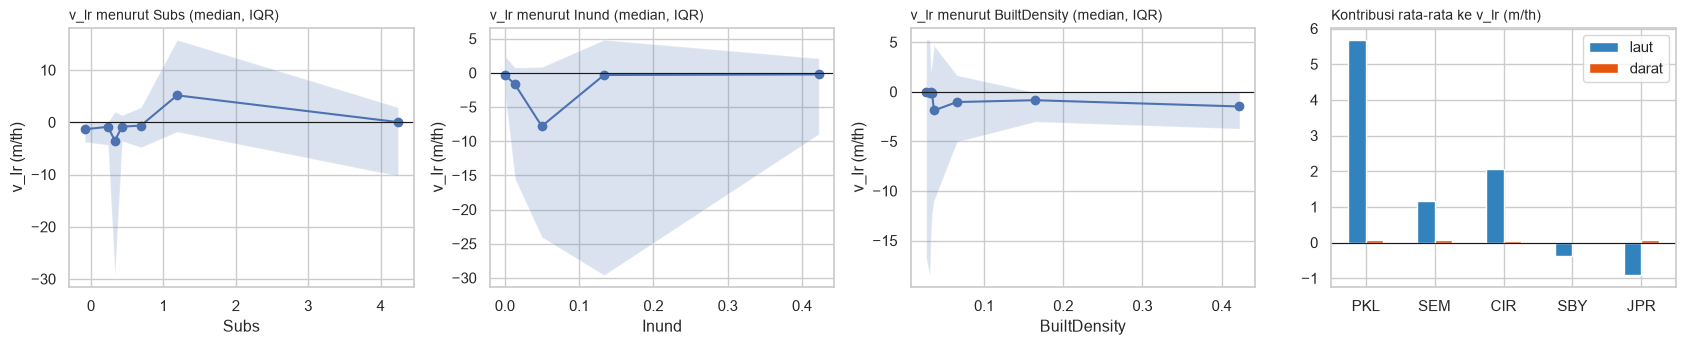

,laut,darat
reg,,
PKL,5.68,0.07
SEM,1.18,0.07
CIR,2.07,0.06
SBY,-0.37,-0.02
JPR,-0.91,0.07


In [22]:
from libpysal.weights import DistanceBand
from esda.moran import Moran
w5 = DistanceBand(cxy[d5.index], threshold=1000, binary=True, silence_warnings=True)
w5.transform = "r"
mi = Moran(m_ols.resid.to_numpy(), w5, permutations=999)
print(f"Moran's I residu OLS = {mi.I:.3f} (p = {mi.p_sim:.3f})" +
      (" -> residu berautokorelasi spasial; galat baku OLS memakai cluster per rangkaian transek" if mi.p_sim < 0.05 else ""))

# p-value Huber mengasumsikan transek independen -> selang kepercayaan dengan bootstrap klaster (rangkaian transek)
rng = np.random.default_rng(42); runs = d5.run.unique(); boot = []
for _ in range(999):
    pick = rng.choice(runs, len(runs), replace=True)
    db = pd.concat([d5[d5.run == r] for r in pick])
    zb = (db[X5] - db[X5].mean()) / db[X5].std()
    boot.append(sm.RLM(db.v_lr.to_numpy(), sm.add_constant(zb).to_numpy(), M=sm.robust.norms.HuberT()).fit().params[1:])
boot = np.array(boot)
ci = pd.DataFrame({"γ Huber": m_hub.params[X5].to_numpy(), "CI95 bawah": np.percentile(boot, 2.5, 0), "CI95 atas": np.percentile(boot, 97.5, 0),
                   "P(γ > 0) bootstrap": (boot > 0).mean(0)}, index=X5)
print("Bootstrap klaster (999 ulangan, 64 rangkaian transek):")
display(tabel(ci.round(3), "05_bootstrap_klaster_huber"))

# kontribusi sisi laut vs darat terhadap v_lr prediksi
g = m1.params
d5["laut"] = g["Subs"] * z5.Subs + g["Inund"] * z5.Inund
d5["darat"] = g["BuiltDensity"] * z5.BuiltDensity
kontrib = d5.groupby("reg")[["laut", "darat"]].mean().reindex(REG)

fig, ax = plt.subplots(1, 4, figsize=(17, 3.6))
for a, x in zip(ax[:3], X5):
    bins = pd.qcut(d5[x], 8, duplicates="drop")
    s = d5.groupby(bins, observed=True).v_lr.agg(["median", lambda v: v.quantile(0.25), lambda v: v.quantile(0.75)])
    mid = [b.mid for b in s.index]
    a.plot(mid, s["median"], "o-"); a.fill_between(mid, s.iloc[:, 1], s.iloc[:, 2], alpha=0.2)
    a.axhline(0, c="k", lw=0.8); a.set_xlabel(x); a.set_ylabel("v_lr (m/th)"); a.set_title(f"v_lr menurut {x} (median, IQR)", loc="left", fontsize=10)
kontrib.plot.bar(ax=ax[3], rot=0, color=["#3182bd", "#e6550d"]); ax[3].axhline(0, c="k", lw=0.8)
ax[3].set_title("Kontribusi rata-rata ke v_lr (m/th)", loc="left", fontsize=10); ax[3].set_xlabel("")
plt.tight_layout(); simpan("05_dua_tekanan"); plt.show()
kontrib.round(2)

**Interpretasi: tekanan sisi laut (amblesan) adalah penggerak mundurnya tepi; tekanan sisi darat tidak.**

1. **Amblesan.** Semua penduga memberi arah positif: tanah yang turun lebih cepat → tepi mundur lebih cepat.
   Huber +1,1 m/th per 1 SD amblesan (≈ 0,8 cm/th), regresi median +0,6, OLS + efek wilayah +6,8 (p = 0,04).
   Setelah dependensi spasial diperhitungkan dengan bootstrap klaster, selang 95% [−0,04; 3,3] dan
   P(γ > 0) = 0,97: **bukti sedang–kuat** untuk efek amblesan. Bukti non-parametrik searah: proporsi transek
   yang mundur naik dari 33% (amblesan ≤ 0,5 cm/th) menjadi 59% (1–2 cm/th) dan 67% (> 4 cm/th).
2. **Genangan** tidak berpengaruh setelah amblesan dikontrol (p ≥ 0,29 di semua penduga), kemungkinan karena
   genangan adalah **akibat** amblesan (ρ = 0,39, Bagian 2.6), bukan penyebab terpisah.
3. **Kawasan terbangun** tidak memengaruhi *laju* tepi (p ≥ 0,2). Tekanan sisi darat bekerja lewat mekanisme
   lain: bukan mempercepat mundurnya tepi, tetapi **membatasi ruang** ke mana tepi bisa mundur (Bagian 6).
4. Kekuatan penjelas rendah (R² OLS 0,008–0,036): laju tepi per transek didominasi derau deteksi dan faktor lokal
   (sedimen, gelombang) yang tidak terukur. Kesimpulan yang aman adalah **arah dan konsistensi** efek, bukan prediksi
   laju per transek.

Kontribusi rata-rata sisi laut terbesar di **PKL (+5,7 m/th)**, CIR (+2,1), dan SEM (+1,2); di SBY dan JPR negatif
(amblesan di bawah rata-rata domain). Ini menjadi dasar sumbu "tekanan laut" pada tipologi Bagian 7.

## 6. Peluang ruang tertutup, kelayakan restorasi, dan risiko keterpaparan

**Ruang gerak dan lajunya.** $MS_i = B^{hard}_{i,2026} - \hat\mu_{i,T}$. Ruang menyempit dari dua arah: tepi mundur
($v_i$, Bagian 4) dan penghalang baru yang muncul lebih dekat ke laut. Penghalang baru adalah **perubahan bertingkat**
(tol/bangunan selesai dibangun), bukan tren, sehingga **tidak diekstrapolasi**: dampaknya sudah masuk ke $MS_i$ saat
ini dan dilaporkan terpisah. Laju penyempitan untuk peluang = laju tepi, $v^{MS}_i = v_i$ (panduan 5.3).

**Peluang tertutup** (panduan 5.3):
$$P(\text{Closed}_h) = \Phi\!\left(\frac{0 - (MS_i - h\, v^{MS}_i)}{\sqrt{\sigma^2_{\mu,i} + \sigma_B^2 + h^2 \sigma^2_{v,i}}}\right),\quad h \in \{1, 5\}\ \text{tahun}$$

**RFI** (panduan 5.4, bobot sama 0,25): peringkat persentil ruang peluang, HydroSuitability, (1 − peringkat amblesan),
dan (1 − P(Closed₁)). **PERI** = P(Closed₅) × log₁₀(Pop + 1), Pop = penduduk 2026 radius 1 km.

Sumber penyempitan ruang gerak Des 2021 -> Agu 2026 (transek domain):


,transek,penghalang_baru,ruang_hilang_median_m,tepi_mundur_median_m
reg,,,,
PKL,17,0.18,10.0,0.00
SEM,107,0.14,10.0,8.89
CIR,40,0.05,35.0,-11.18
SBY,538,0.20,20.0,-2.14
JPR,4,0.00,NaN,-70.16


,MS_median,tersensor,vMS_median,penghalang_baru,P1_gt_0_6,P5_gt_0_7,P5_median,RFI_median,PERI_median
reg,,,,,,,,,
PKL,2378.52,0.18,0.00,0.18,0.0,0.0,0.0,0.52,0.0
SEM,2649.83,0.60,0.36,0.14,0.0,0.0,0.0,0.55,0.0
CIR,2974.40,0.68,-0.23,0.05,0.0,0.0,0.0,0.56,0.0
SBY,1982.93,0.41,-0.06,0.20,0.0,0.0,0.0,0.60,0.0
JPR,2902.18,1.00,-2.75,0.00,0.0,0.0,0.0,0.67,0.0


Transek dengan tepi mundur (v_lr > 0): 259 dari 706. Waktu sampai ruang habis bila laju bertahan:


,count,10%,50%,habis_lt_25th
reg,,,,
PKL,4.0,125.3,808.5,0.0
SEM,51.0,33.9,272.7,4.0
CIR,12.0,278.2,1555.3,0.0
SBY,192.0,65.4,542.5,5.0
JPR,NaN,NaN,NaN,NaN


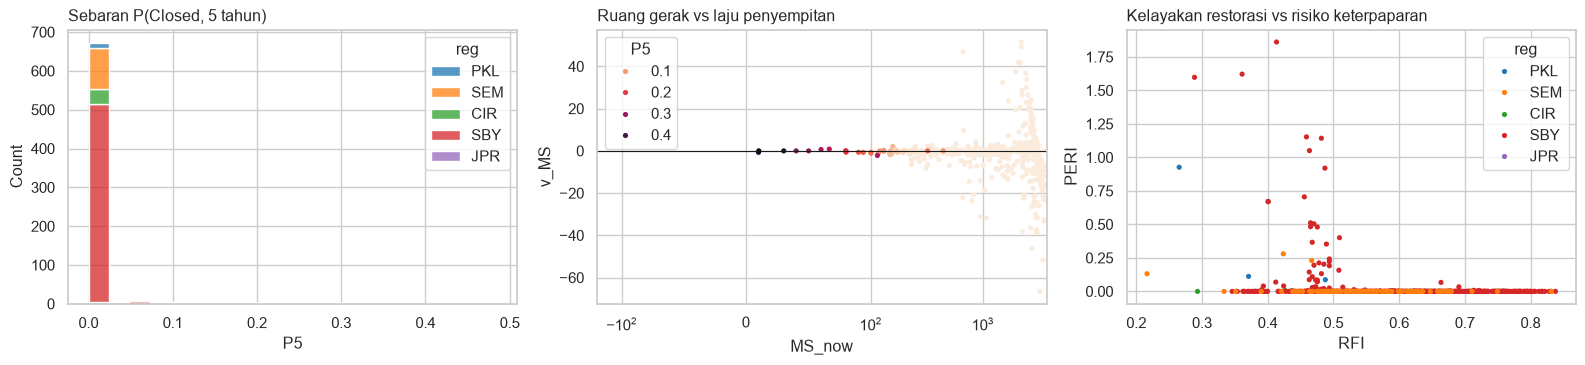

In [23]:
MS_NOW = B_HARD[:, -1] - MU_T
V_MS = V_KF          # ruang menyempit bila tepi mundur (panduan 5.3)

# Penghalang baru 2021->2026: perubahan bertingkat (sekali terjadi), bukan tren -> dilaporkan, tidak diekstrapolasi.
# Dihitung hanya bila posisi 2025 = 2026 (+-20 m), supaya piksel built DW yang berkedip tidak terhitung.
tetap = np.abs(B_HARD[:, -1] - B_HARD[:, -2]) <= 20
DMS_B = np.where(tetap, np.clip(B_HARD[:, 0] - B_HARD[:, -1], 0, None), 0.0)     # ruang hilang karena penghalang baru (m)
MS_2021 = B_HARD[:, 0] - X_kf[:, 11, 0]
pb = pd.DataFrame({"reg": REG_D, "ms_hilang": DMS_B, "mundur_tepi_m": X_kf[:, -1, 0] - X_kf[:, 11, 0]})
print("Sumber penyempitan ruang gerak Des 2021 -> Agu 2026 (transek domain):")
display(pb.groupby("reg").agg(transek=("ms_hilang", "size"), penghalang_baru=("ms_hilang", lambda s: (s > 0).mean()),
                              ruang_hilang_median_m=("ms_hilang", lambda s: s[s > 0].median()),
                              tepi_mundur_median_m=("mundur_tepi_m", "median")).reindex(REG).round(2))
def p_closed(ms, vms, sd_mu, sd_v, h):
    return norm.cdf((0 - (ms - h * vms)) / np.sqrt(sd_mu ** 2 + PARAM["SIGMA_B"] ** 2 + h ** 2 * sd_v ** 2))
P1, P5 = p_closed(MS_NOW, V_MS, SD_MU, SD_V, 1), p_closed(MS_NOW, V_MS, SD_MU, SD_V, 5)
rk = lambda v: pd.Series(v).rank(pct=True).to_numpy()
RFI = 0.25 * rk(OPP) + 0.25 * HYD + 0.25 * (1 - rk(SUBS)) + 0.25 * (1 - P1)
POP = TR.pop_2026.to_numpy()[iD]
PERI = P5 * np.log10(POP + 1)
R6 = pd.DataFrame({"transek_id": IDS[iD], "reg": REG_D, "MS_now": MS_NOW, "B_tersensor": B_SENS[:, -1], "v_MS": V_MS, "MS_hilang_penghalang_baru": DMS_B,
                   "P1": P1, "P5": P5, "RFI": RFI, "Space_opp": OPP, "HydroSuit": HYD, "Pop": POP, "PERI": PERI})
ring6 = R6.groupby("reg").agg(MS_median=("MS_now", "median"), tersensor=("B_tersensor", "mean"), vMS_median=("v_MS", "median"), penghalang_baru=("MS_hilang_penghalang_baru", lambda s: (s > 0).mean()),
                              P1_gt_0_6=("P1", lambda p: (p > 0.6).mean()), P5_gt_0_7=("P5", lambda p: (p > 0.7).mean()),
                              P5_median=("P5", "median"), RFI_median=("RFI", "median"), PERI_median=("PERI", "median")).reindex(REG)
display(tabel(ring6.round(2), "06_ringkasan_risiko"))

# horizon lebih panjang: waktu sampai ruang habis bila laju jangka panjang tepi (Bag. 5) bertahan
R6["v_lr"] = Y_lr
R6["tahun_habis"] = np.where(R6.v_lr > 0, R6.MS_now / R6.v_lr, np.inf)
th = R6[R6.v_lr > 0]
print(f"Transek dengan tepi mundur (v_lr > 0): {len(th)} dari {ND}. Waktu sampai ruang habis bila laju bertahan:")
display(tabel(th.groupby("reg").tahun_habis.describe(percentiles=[0.1, 0.5]).reindex(REG)[["count", "10%", "50%"]]
              .assign(habis_lt_25th=th.groupby("reg").tahun_habis.apply(lambda s: (s < 25).sum()).reindex(REG)).round(1), "06_waktu_habis"))
fig, ax = plt.subplots(1, 3, figsize=(16, 3.8))
sns.histplot(R6, x="P5", hue="reg", hue_order=REG, palette=REG_WARNA, bins=20, multiple="stack", ax=ax[0]); ax[0].set_title("Sebaran P(Closed, 5 tahun)", loc="left")
sns.scatterplot(R6, x="MS_now", y="v_MS", hue="P5", palette="rocket_r", s=14, ax=ax[1], edgecolor="none")
ax[1].set_xscale("symlog", linthresh=100); ax[1].axhline(0, c="k", lw=0.8); ax[1].set_title("Ruang gerak vs laju penyempitan", loc="left")
sns.scatterplot(R6, x="RFI", y="PERI", hue="reg", hue_order=REG, palette=REG_WARNA, s=14, ax=ax[2], edgecolor="none"); ax[2].set_title("Kelayakan restorasi vs risiko keterpaparan", loc="left")
plt.tight_layout(); simpan("06_risiko"); plt.show()

**Interpretasi.**

- **Coastal squeeze belum akut dalam horizon 1–5 tahun.** Ruang gerak median 2,0–3,0 km, sedangkan tepi hampir diam,
  sehingga tidak ada transek domain dengan $P(\text{Closed}_5) > 0{,}7$. Peluang tertinggi hanya di transek yang
  penghalangnya sudah dekat (maksimum 0,48).
- **Penghalang baru 2021→2026** muncul di 5–20% transek domain, tetapi ruang yang hilang kecil (median 10–35 m).
  Penyempitan ruang dalam periode studi bukan akibat pembangunan besar-besaran di belakang tegakan mangrove.
- **Horizon lebih panjang**: dari 259 transek yang tepinya mundur, ruang habis dalam < 25 tahun hanya pada 9 transek
  (SEM 4, SBY 5) bila laju saat ini bertahan; median waktu habis ratusan tahun.
- Karena $P(\text{Closed}_5)$ hampir nol di mayoritas transek, **PERI terkonsentrasi di sedikit transek** yang
  ruangnya sempit dan padat penduduk. Risiko keterpaparan di Pantura ditentukan oleh **jarak penghalang yang sudah
  ada**, bukan oleh kecepatan mundur tepi.

## 7. Kerangka intervensi multi-skala

### 7.1 Hotspot PERI (Getis-Ord Gi*)

Bobot `DistanceBand` biner 1.000 m antar titik pusat transek domain; transek tanpa tetangga (isolat) tidak diberi nilai.
Hotspot = $z_{Gi^*} > 1{,}96$.

In [24]:
from esda.getisord import G_Local
wg = DistanceBand(cxy, threshold=1000, binary=True, silence_warnings=True)
iso = np.array([wg.cardinalities[k] == 0 for k in range(ND)])
gl = G_Local(PERI, wg, transform="B", star=True, permutations=999, seed=42)
GI_Z = np.where(iso, np.nan, gl.Zs); HOT = GI_Z > 1.96
R6["Gi_z"], R6["hotspot"] = GI_Z, HOT
print(f"isolat: {iso.sum()} transek; hotspot PERI: {HOT.sum()} transek")
display(R6.groupby("reg").agg(hotspot=("hotspot", "sum"), proporsi=("hotspot", "mean")).reindex(REG).round(2))

C:\Users\ASUS\Documents\Lomba\ARSEN 2026\mangrove\code\data_acquisition\.venv\Lib\site-packages\libpysal\weights\util.py:819: UserWarning: The weights matrix is not fully connected: 
 There are 67 disconnected components.
  w = W(neighbors, weights, ids, **kwargs)


isolat: 16 transek; hotspot PERI: 29 transek


,hotspot,proporsi
reg,,
PKL,4,0.24
SEM,0,0.00
CIR,0,0.00
SBY,25,0.05
JPR,0,0.00


**Interpretasi.** Hotspot PERI terbentuk di **SBY (25 transek)** dan **PKL (4)**: di SBY karena penghalang keras
dekat dengan tegakan dan penduduk padat (estuari perkotaan), di PKL karena ruang sempit di zona amblesan tinggi.
SEM dan CIR tidak punya hotspot karena ruang di belakang tegakannya masih lebar dan penduduk dalam 1 km relatif
sedikit. Bobot jarak 1 km membuat 67 komponen terpisah (celah muara/pelabuhan > 1 km tidak disambung), sesuai
tujuan panduan agar hotspot tidak "melompati" celah.

### 7.2 Tipologi 4 aksi per transek

Matriks panduan 6.2 dioperasionalkan dengan dua sumbu eksplisit supaya setiap transek punya satu kelas:

- **Tekanan laut tinggi**: amblesan ≥ 1 cm/th (melampaui laju akresi vertikal mangrove yang umumnya ≤ ±1 cm/th)
  **atau** genangan di belakang tepi di atas batas atas jendela hidroperiode (terlalu basah untuk mangrove perintis).
- **Tekanan darat tinggi**: penghalang keras ≤ 500 m di belakang tepi (tidak tersensor), **atau** transek memotong
  tapak tol/tanggul laut (PSN).

| | darat tinggi | darat rendah |
|---|---|---|
| **laut tinggi** | RED – hybrid engineering | ORANGE – managed realignment |
| **laut rendah** | YELLOW – assisted regeneration | GREEN – strict conservation |

Kriteria angka panduan (P(Closed₁) > 0,6 untuk RED; P(Closed₅) > 0,7 dan RFI > 0,6 untuk ORANGE) dipakai sebagai
**pemeriksaan koherensi**: kelas yang lebih parah harus punya peluang tertutup lebih tinggi.

In [25]:
psn_tr = set(BAR[BAR.jenis.str.contains("motorway|construction", na=False)].transek_id)
PSN = np.isin(IDS[iD], list(psn_tr))
LAUT_T = (SUBS >= PARAM["SUBS_HIGH"]) | (INUND_I > JENDELA[1])
DARAT_T = ((MS_NOW <= PARAM["MS_DEKAT"]) & ~B_SENS[:, -1]) | PSN
TIPE = np.select([LAUT_T & DARAT_T, LAUT_T & ~DARAT_T, ~LAUT_T & DARAT_T], ["RED", "ORANGE", "YELLOW"], "GREEN")
R6["laut_tinggi"], R6["darat_tinggi"], R6["PSN"], R6["tipe"] = LAUT_T, DARAT_T, PSN, TIPE
URUT_T = ["RED", "ORANGE", "YELLOW", "GREEN"]
WARNA_T = {"RED": "#d7301f", "ORANGE": "#fc8d59", "YELLOW": "#fee08b", "GREEN": "#1a9850", "ABU": "#bdbdbd"}
kt = pd.crosstab(R6.reg, R6.tipe).reindex(index=REG, columns=URUT_T, fill_value=0)
display(kt)
koh = R6.groupby("tipe").agg(n=("P1", "size"), P1_median=("P1", "median"), P5_median=("P5", "median"), RFI_median=("RFI", "median"),
                             MS_median=("MS_now", "median"), Subs_median=("reg", lambda s: np.median(SUBS[s.index])),
                             kriteria_panduan_RED=("P1", lambda p: (p > 0.6).mean()),
                             kriteria_panduan_ORANGE=("P5", lambda p: ((p > 0.7) & (R6.RFI[p.index] > 0.6)).mean())).reindex(URUT_T)
tabel(koh.round(2), "07_koherensi_tipologi")

tipe,RED,ORANGE,YELLOW,GREEN
reg,,,,
PKL,2,15,0,0
SEM,3,79,0,25
CIR,0,38,2,0
SBY,0,38,102,398
JPR,0,0,0,4


,n,P1_median,P5_median,RFI_median,MS_median,Subs_median,kriteria_panduan_RED,kriteria_panduan_ORANGE
tipe,,,,,,,,
RED,5,0.13,0.15,0.37,320.00,4.10,0.0,0.0
ORANGE,170,0.00,0.00,0.55,2846.71,2.21,0.0,0.0
YELLOW,104,0.00,0.00,0.48,279.97,0.26,0.0,0.0
GREEN,427,0.00,0.00,0.63,2489.22,0.37,0.0,0.0


**Interpretasi.**

- **Urutan kelas koheren.** RED punya ruang tersempit (median 320 m), amblesan tertinggi (4,1 cm/th), dan
  $P(\text{Closed}_5)$ tertinggi (median 0,15). YELLOW juga sempit (280 m) tetapi amblesannya rendah. ORANGE dan
  GREEN punya ruang lebar (2,5–2,8 km).
- **Pola wilayah sesuai arketipe desain.** ORANGE (tekanan laut tinggi, ruang darat lapang) mendominasi **SEM (79)**,
  **CIR (38)**, dan **PKL (15)**; YELLOW (ruang sempit karena kota, amblesan rendah) hampir seluruhnya di **SBY (102)**.
- **Kriteria angka panduan hampir tidak pernah terpenuhi** (P(Closed₁) > 0,6 untuk RED; P(Closed₅) > 0,7 dan RFI > 0,6
  untuk ORANGE). Ini konsekuensi temuan Bagian 6 (tepi hampir diam, ruang lebar), bukan kesalahan klasifikasi. Karena
  itu tipologi didasarkan pada dua sumbu tekanan yang terukur langsung, dan peluang tertutup dipakai untuk
  mengurutkan prioritas di dalam kelas.

### 7.3 Transek tanpa tegakan mangrove: kandidat restorasi baru

Transek di luar domain (tanpa mangrove WorldCover) tidak punya tepi dan laju, tetapi bisa menjadi lokasi
**restorasi baru**. Kelayakannya dinilai dari ruang peluang di belakang garis pantai basis, kesesuaian
hidroperiode, dan amblesan: $RFI^{baru} = \tfrac13[\text{rank}(Space_{opp}) + HydroSuit + (1 - \text{rank}(Subs))]$.

In [26]:
iN = np.flatnonzero(~DOM)
def penghalang_keras_set(tau_built, y0, iset):
    H = DW[iset, :, 5, 3] > tau_built
    H = H & np.concatenate([H[:, 1:], np.zeros((len(iset), 1), bool)], 1)
    br = BAR[BAR.i.isin(iset)]
    pos = {v: k for k, v in enumerate(iset)}
    H[br.i.map(pos).to_numpy(), br.j.to_numpy()] = True
    H &= DIST[None, :] > y0
    return np.where(H.any(1), H.argmax(1) * STEP, DIST[-1])
BH_N = penghalang_keras_set(PARAM["TAU_BUILT"], LEN_SEA, iN)
BS_N, OPP_N, HYD_N = ruang_peluang(np.full(len(iN), float(LEN_SEA)), BH_N, iN)
SUBS_N = TR.subs_rate.to_numpy()[iN]; SUBS_N = np.where(np.isnan(SUBS_N), np.nanmedian(SUBS_N), SUBS_N)
RFI_BARU = (rk(OPP_N) + HYD_N + (1 - rk(SUBS_N))) / 3
RN = pd.DataFrame({"transek_id": IDS[iN], "reg": REG_I[iN], "Space_opp": OPP_N, "HydroSuit": HYD_N, "Subs": SUBS_N, "RFI_baru": RFI_BARU})
RN["kandidat"] = (RN.RFI_baru > 0.6) & (RN.Space_opp >= 200) & (RN.Subs < PARAM["SUBS_HIGH"])
RN["tol_konstruksi"] = RN.transek_id.isin(psn_tr)
RN["kelas"] = np.select([RN.kandidat, RN.Subs >= PARAM["SUBS_HIGH"]],
                        ["kandidat restorasi baru", "amblesan >= 1 cm/th (restorasi biasa tidak layak)"], "lainnya")
display(tabel(pd.crosstab(RN.reg, RN.kelas).reindex(REG).assign(
    Space_opp_median_kandidat=RN[RN.kandidat].groupby("reg").Space_opp.median().reindex(REG)).fillna(0), "07_tanpa_mangrove"))
kons_tr = set(BAR[BAR.jenis.str.contains("construction", na=False)].transek_id)
tol = RN[RN.transek_id.isin(kons_tr) & (RN.reg == "SEM")]
print(f"Tol tanggul laut Semarang–Demak (ruas highway=construction di SEM): {len(tol)} transek, semuanya tanpa mangrove "
      f"WorldCover 2021; amblesan {tol.Subs.min():.1f}–{tol.Subs.max():.1f} cm/th; kelas: {tol.kelas.value_counts().to_dict()}")
print(f"(Seluruh transek tanpa mangrove yang memotong jalan tol atau ruas konstruksi: {int(RN.tol_konstruksi.sum())})")

kelas,amblesan >= 1 cm/th (restorasi biasa tidak layak),kandidat restorasi baru,lainnya,Space_opp_median_kandidat
reg,,,,
PKL,119,28,126,1195.0
SEM,160,20,28,2990.0
CIR,197,98,70,2990.0
SBY,7,32,588,2650.0
JPR,0,33,153,1100.0


Tol tanggul laut Semarang–Demak (ruas highway=construction di SEM): 22 transek, semuanya tanpa mangrove WorldCover 2021; amblesan 7.1–9.7 cm/th; kelas: {'amblesan >= 1 cm/th (restorasi biasa tidak layak)': 22}
(Seluruh transek tanpa mangrove yang memotong jalan tol atau ruas konstruksi: 85)


**Interpretasi.**

- **Cirebon adalah lokasi restorasi baru terbesar**: 98 transek tanpa mangrove memenuhi syarat (ruang peluang median
  ±3,0 km, amblesan < 1 cm/th, hidroperiode cocok), jauh di atas wilayah lain. Ini sejalan dengan peran CIR sebagai
  arketipe *managed realignment*: tegakannya sedikit, tetapi tambak lapang yang bisa dikembalikan ke pasang-surut.
- **Tol tanggul laut Semarang–Demak** memotong 22 transek yang **tidak lagi bermangrove** (WorldCover 2021 = air) dengan
  amblesan **7–10 cm/th**, jauh di atas laju akresi mangrove. Di ruas ini, penanaman biasa tidak akan bertahan;
  intervensinya adalah rekayasa hibrida (perangkap sedimen permeabel) sebelum revegetasi, sesuai logika tipologi RED,
  meskipun transeknya berada di luar domain tegakan.

### 7.4 Kawasan prioritas (agregasi transek → segmen pantai, panduan 6.3)

Semua transek diurutkan sepanjang pantai; transek tanpa mangrove diberi kelas **ABU** (tidak dinilai untuk tipologi
tegakan). Celah > 1 km memutus rangkaian, tipologi dihaluskan dengan modus 5 transek, dan kawasan < 4 transek
(1 km) dilebur ke tetangga.

kawasan               panjang_km              
tipologi   GREEN ORANGE YELLOW      GREEN ORANGE YELLOW
wilayah                                                
CIR            0      6      0       0.00   6.75    0.0
JPR            1      0      0       1.25   0.00    0.0
PKL            0      2      0       0.00   3.50    0.0
SBY           24      5     10     100.25   8.25   24.5
SEM            4      8      0       6.00  20.25    0.0

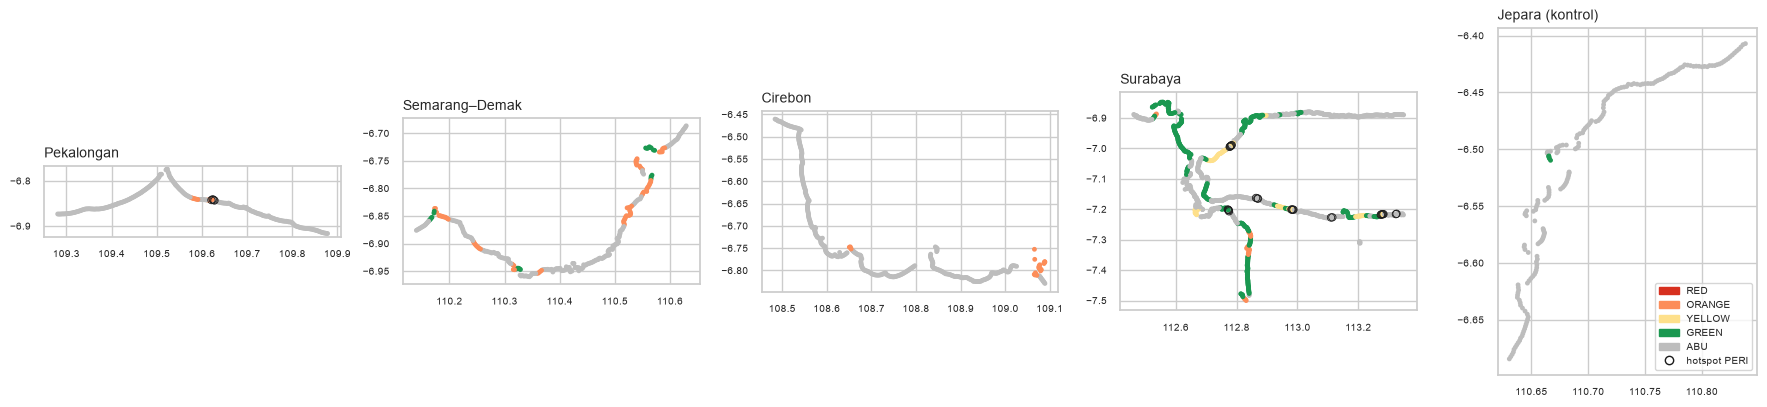

In [27]:
SEVERITY = {"RED": 4, "ORANGE": 3, "YELLOW": 2, "GREEN": 1, "ABU": 0}
def build_priority_zones(df, gap_m=1000, window=5, min_len=4):
    df = df.sort_values(["region_code", "transek_id"]).copy()
    step = np.hypot(df.cx.diff(), df.cy.diff())
    df["run_id"] = ((df.region_code != df.region_code.shift()) | (step > gap_m)).cumsum()
    def smooth(typ):
        half = window // 2; out = []
        for k in range(len(typ)):
            c = pd.Series(typ[max(0, k - half): k + half + 1]).value_counts()
            out.append(max(c[c == c.max()].index, key=SEVERITY.get))
        return out
    def merge_short(typ):
        typ = list(typ)
        while True:
            blocks = []
            for k, c in enumerate(typ):
                if blocks and blocks[-1][2] == c: blocks[-1][1] = k + 1
                else: blocks.append([k, k + 1, c])
            short = [b for b in blocks if b[1] - b[0] < min_len]
            if len(blocks) == 1 or not short: return typ
            b = min(short, key=lambda x: x[1] - x[0]); i = blocks.index(b)
            nb = [blocks[j] for j in (i - 1, i + 1) if 0 <= j < len(blocks)]
            tgt = max(nb, key=lambda x: (x[1] - x[0], SEVERITY[x[2]]))
            typ[b[0]: b[1]] = [tgt[2]] * (b[1] - b[0])
    df["typ_smooth"] = df.groupby("run_id").typ.transform(lambda t: smooth(list(t)))
    df["typ_kawasan"] = df.groupby("run_id").typ_smooth.transform(merge_short)
    change = (df.run_id != df.run_id.shift()) | (df.typ_kawasan != df.typ_kawasan.shift())
    df["kawasan_id"] = df.region_code + "_K" + change.cumsum().astype(str).str.zfill(3)
    return df

ALL = TR[["region_code", "cx", "cy", "lon", "lat", "n_silang_pantai", "pop_2026"]].reset_index()
ALL["typ"] = "ABU"; ALL.loc[iD, "typ"] = TIPE
KAW = build_priority_zones(ALL)
kaw = KAW.groupby("kawasan_id").agg(wilayah=("region_code", "first"), tipologi=("typ_kawasan", "first"), transek=("transek_id", "size"),
                                    pop=("pop_2026", "sum"), multi_silang=("n_silang_pantai", lambda s: (s > 1).mean()))
kaw["panjang_km"] = kaw.transek * 0.25
r6i = R6.set_index("transek_id")
kaw = kaw.join(KAW.groupby("kawasan_id").transek_id.apply(lambda s: pd.Series({"P5_median": r6i.P5.reindex(s).median(),
                                                                                 "RFI_median": r6i.RFI.reindex(s).median()})).unstack())
ks = kaw[kaw.tipologi != "ABU"].groupby(["wilayah", "tipologi"]).agg(kawasan=("transek", "size"), panjang_km=("panjang_km", "sum")).unstack(fill_value=0)
display(ks)
fig, axs = plt.subplots(1, 5, figsize=(18, 4.2))
for a, r in zip(axs, REG):
    s = KAW[KAW.region_code == r]
    a.scatter(s.lon, s.lat, c=s.typ_kawasan.map(WARNA_T), s=6)
    h = R6[(R6.reg == r) & R6.hotspot]; hh = TR.loc[h.transek_id]
    a.scatter(hh.lon, hh.lat, facecolors="none", edgecolors="k", s=28, lw=0.6)
    a.set_title(REG_NAMA[r], loc="left", fontsize=10); a.set_aspect("equal"); a.tick_params(labelsize=7)
from matplotlib.patches import Patch
axs[-1].legend(handles=[Patch(color=WARNA_T[k], label=k) for k in URUT_T + ["ABU"]] + [plt.Line2D([], [], marker="o", mfc="none", mec="k", ls="", label="hotspot PERI")],
               fontsize=7, loc="lower right")
plt.tight_layout(); simpan("07_peta_kawasan"); plt.show()

**Interpretasi.** Setelah penghalusan dan panjang minimum 1 km, **kelas RED lenyap di tingkat kawasan**: kelima transek
RED tersebar (2 di PKL, 3 di SEM) dan tidak membentuk ruas ≥ 1 km, sehingga dilebur ke kawasan ORANGE di sekitarnya.
Transek RED tetap tercatat di tingkat mikro (`Intervention_Type`) sebagai titik rekayasa hibrida. Di tingkat kawasan:

- **ORANGE** = 38,8 km pantai, terpanjang di **SEM (20,3 km)**, lalu SBY (8,3), CIR (6,8), dan PKL (3,5): prioritas
  program restorasi hidrologis tambak;
- **YELLOW** = 24,5 km, seluruhnya di **SBY**, dan berimpit dengan hotspot PERI: pengayaan sabuk hijau di depan kota;
- **GREEN** = 107,5 km, terutama SBY (100 km): konservasi dan pemantauan.

## 8. Uji sensitivitas dan ketahanan

**36 skenario** = τ_veg {0,3; 0,4; 0,5} × τ_built {0,4; 0,5; 0,6} × τ_SAR {−17; −16; −15; −14 dB}.
**[Penyesuaian]** Panduan memakai spasi transek sebagai faktor ketiga; transek sudah tetap 250 m sehingga spasi
tidak bisa diubah tanpa mengulang ekstraksi GEE. Faktor ketiga diganti τ_SAR, yang terbukti paling berpengaruh
(Bagian 3.1) dan mencakup nilai panduan −14 dB.

Setiap skenario mengulang rantai Y → Kalman (parameter tetap) → MS → P(Closed₅) → PERI → tipologi.
Ketahanan = korelasi Spearman peringkat PERI terhadap skenario dasar (target ρ > 0,90) dan kesamaan tipologi.

36 skenario dalam 27 s; ρ_PERI > 0,90 pada 36/36 skenario (min 0.96, median 0.99); tipologi sama median 98%


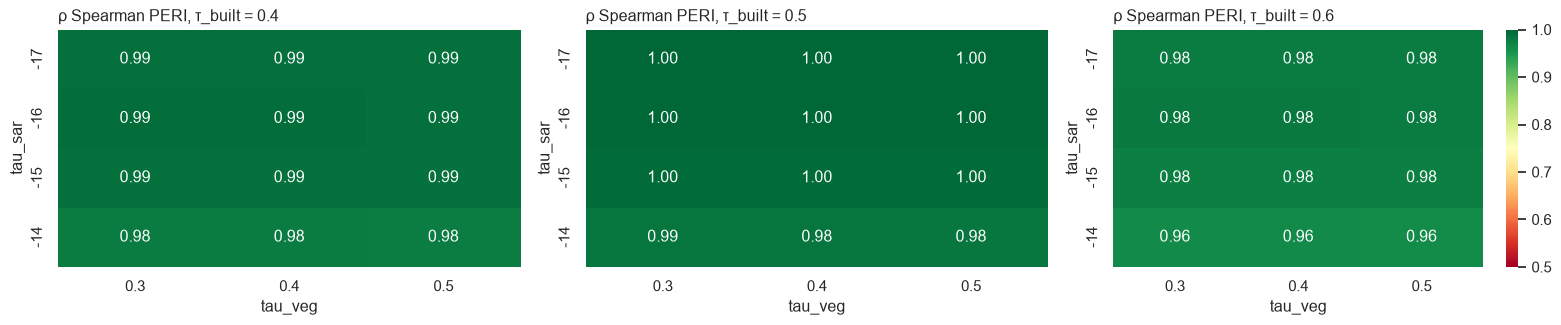

,tau_veg,tau_built,tau_sar,rho_PERI,rho_P5,tipologi_sama,obs_Y
0,0.3,0.4,-17,0.992,0.989,0.993,0.576
1,0.3,0.4,-16,0.993,0.991,0.993,0.554
2,0.3,0.4,-15,0.989,0.985,0.986,0.508
3,0.3,0.4,-14,0.979,0.970,0.977,0.419
4,0.3,0.5,-17,0.998,0.998,0.999,0.576
5,0.3,0.5,-16,1.000,1.000,1.000,0.554
6,0.3,0.5,-15,0.996,0.994,0.994,0.508
7,0.3,0.5,-14,0.986,0.977,0.982,0.419
8,0.3,0.6,-17,0.980,0.973,0.983,0.576
9,0.3,0.6,-16,0.981,0.975,0.984,0.554


In [28]:
par_fix = PAR
def rantai(tv, ts, tb):
    Yr = deteksi_tepi(tv, ts, batas=BATAS[iD], iset=iD); Yc, _ = hampel(Yr)
    yref = np.stack([np.nanmedian(Yc[:, TH_T == y], 1) for y in TAHUN], 1)
    yref = pd.DataFrame(yref).ffill(axis=1).bfill(axis=1).fillna(LEN_SEA).to_numpy()
    Bh, Bs = penghalang_keras(tb, yref)
    X, PPk = filter_semua(Yc, REG_D, par_fix)
    mu, sdmu, v, sdv = X[:, -1, 0], np.sqrt(PPk[:, -1, 0, 0]), 12 * X[:, -1, 1], 12 * np.sqrt(PPk[:, -1, 1, 1])
    ms = Bh[:, -1] - mu; vms = v
    p5 = p_closed(ms, vms, sdmu, sdv, 5); peri = p5 * np.log10(POP + 1)
    darat = ((ms <= PARAM["MS_DEKAT"]) & ~Bs[:, -1]) | PSN
    tipe = np.select([LAUT_T & darat, LAUT_T & ~darat, ~LAUT_T & darat], ["RED", "ORANGE", "YELLOW"], "GREEN")
    return pd.DataFrame({"P5": p5, "PERI": peri, "tipe": tipe, "obs": np.isfinite(Yc).mean(1)})

t0 = time.time(); sens = []
dasar = rantai(PARAM["TAU_VEG"], PARAM["TAU_SAR"], PARAM["TAU_BUILT"])
for tv in [0.3, 0.4, 0.5]:
    for tb in [0.4, 0.5, 0.6]:
        for ts in [-17, -16, -15, -14]:
            r = rantai(tv, ts, tb)
            sens.append(dict(tau_veg=tv, tau_built=tb, tau_sar=ts, rho_PERI=spearmanr(dasar.PERI, r.PERI, nan_policy="omit")[0],
                             rho_P5=spearmanr(dasar.P5, r.P5, nan_policy="omit")[0], tipologi_sama=(dasar.tipe == r.tipe).mean(),
                             obs_Y=r.obs.mean()))
sens = pd.DataFrame(sens)
print(f"36 skenario dalam {time.time() - t0:.0f} s; ρ_PERI > 0,90 pada {(sens.rho_PERI > 0.9).sum()}/36 skenario "
      f"(min {sens.rho_PERI.min():.2f}, median {sens.rho_PERI.median():.2f}); tipologi sama median {sens.tipologi_sama.median():.0%}")
fig, ax = plt.subplots(1, 3, figsize=(16, 3.4))
for a, tb in zip(ax, [0.4, 0.5, 0.6]):
    sns.heatmap(sens[sens.tau_built == tb].pivot(index="tau_sar", columns="tau_veg", values="rho_PERI"), annot=True, fmt=".2f",
                vmin=0.5, vmax=1, cmap="RdYlGn", ax=a, cbar=a is ax[-1])
    a.set_title(f"ρ Spearman PERI, τ_built = {tb}", loc="left")
plt.tight_layout(); simpan("08_sensitivitas"); plt.show()
tabel(sens.round(3), "08_sensitivitas_36")

**Uji tambahan.** (a) Model dua tekanan tanpa transek multi-persilangan pantai (masalah M9); (b) kesamaan peta kawasan
untuk jendela penghalusan 3/5/7 transek dan panjang minimum 2/4/8 transek (0,5/1/2 km).

In [29]:
d5b = d5[~d5.multi_silang]; z5b = (d5b[X5] - d5b[X5].mean()) / d5b[X5].std()
m1b = sm.RLM(d5b.v_lr, sm.add_constant(z5b), M=sm.robust.norms.HuberT()).fit()
print(f"(a) Huber tanpa {int(d5.multi_silang.sum())} transek multi-silang:")
print(pd.DataFrame({"semua": m1.params[X5], "p semua": m1.pvalues[X5], "tanpa multi-silang": m1b.params[X5],
                    "p tanpa multi-silang": m1b.pvalues[X5]}).round(3))
kw = []
bermangrove = (KAW.typ_kawasan != "ABU").to_numpy()      # transek ABU (tanpa mangrove) selalu sama -> tidak dihitung
for w in [3, 5, 7]:
    for ml in [2, 4, 8]:
        z2 = build_priority_zones(ALL, window=w, min_len=ml)
        k2 = z2.set_index("transek_id").typ_kawasan.reindex(KAW.transek_id).to_numpy()
        kw.append(dict(jendela=w, min_transek=ml, kesamaan=(k2[bermangrove] == KAW.typ_kawasan.to_numpy()[bermangrove]).mean(),
                       kawasan=z2.kawasan_id.nunique()))
print("(b) kesamaan tipologi kawasan pada transek bermangrove terhadap dasar (jendela 5, minimum 4 transek):")
tabel(pd.DataFrame(kw).pivot(index="jendela", columns="min_transek", values="kesamaan").round(3), "08_kesamaan_kawasan")

(a) Huber tanpa 49 transek multi-silang:
              semua  p semua  tanpa multi-silang  p tanpa multi-silang
Subs          1.111    0.005               0.833                 0.032
Inund         0.025    0.949              -0.103                 0.787
BuiltDensity -0.154    0.701              -0.246                 0.535


(b) kesamaan tipologi kawasan pada transek bermangrove terhadap dasar (jendela 5, minimum 4 transek):


min_transek,2,4,8
jendela,,,
3,0.944,0.971,0.855
5,0.981,1.000,0.867
7,0.984,0.971,0.874


**Interpretasi.**

- **Peringkat risiko tahan terhadap pilihan ambang.** Pada 36/36 skenario, korelasi peringkat PERI dengan skenario
  dasar ρ ≥ 0,96 (median 0,99), dan 98% transek mendapat tipologi yang sama. Skenario terlemah adalah τ_SAR = −14 dB
  (nilai panduan) dengan τ_built = 0,6: ambang VH tinggi mengurangi bulan terukur ($Y$ terukur 40% vs 55%).
- **Efek amblesan tahan terhadap transek multi-persilangan**: tanpa 49 transek itu, γ Huber = +0,83 m/th per SD
  (p = 0,03).
- **Peta kawasan cukup stabil** untuk jendela penghalusan 3–7 transek dan panjang minimum 0,5–1 km (kesamaan
  0,94–1,0 pada transek bermangrove). Panjang minimum 2 km mengubah ±13% peta karena kawasan pendek di SBY dilebur;
  peta 1 km dipertahankan sebagai dasar, sesuai panduan.

## 9. Sintesis: rantai sebab-akibat dalam angka

### 9.1 Jawaban atas pertanyaan penelitian

**1. Di mana dan seberapa cepat tepi mangrove mundur?** Dari 706 transek bermangrove, tepi hampir diam dalam
2021–2026 (median laju mendekati 0 m/th; simpangan per transek ±20 m/th). Tepi paling cenderung mundur di **SEM**
(median jangka panjang +2,8 m/th) dan **PKL** (+1,5), sedangkan CIR dan SBY sedikit maju. Dalam horizon 6–12 bulan,
posisi tepi paling baik diramal dengan nilai terakhir; Kalman memberi akurasi setara dengan interval yang terkalibrasi.

**2. Apa penggeraknya?** **Amblesan** (tekanan sisi laut). Semakin cepat tanah turun, semakin besar peluang tepi mundur
(33% transek mundur pada amblesan ≤ 0,5 cm/th → 59–67% pada ≥ 1 cm/th; γ Huber +1,1 m/th per SD, P(γ > 0) = 0,97
dengan bootstrap klaster). Genangan tidak memberi efek tambahan, dan **kawasan terbangun tidak mempercepat mundurnya
tepi**; tekanan sisi darat bekerja dengan **membatasi ruang**, bukan mendorong tepi.

**3. Di mana ruang gerak akan habis?** Dalam 5 tahun hampir tidak ada (tidak ada transek dengan P(Closed₅) > 0,7),
karena ruang gerak median 2–3 km dan tepi hampir diam. Risiko **terkonsentrasi di transek yang penghalang kerasnya
sudah ≤ 500 m** di belakang tegakan: 14% transek bermangrove (SBY 17%, PKL 12%), membentuk 29 transek hotspot PERI,
terutama di pesisir perkotaan Surabaya.

**4. Intervensi apa?**

| Tipologi | Transek | Wilayah utama | Aksi |
|---|---|---|---|
| RED | 5 | PKL, SEM | rekayasa hibrida (perangkap sedimen permeabel) sebelum revegetasi |
| ORANGE | 170 (38,8 km kawasan) | SEM, CIR, PKL | *managed realignment*: buka pematang tambak di belakang tegakan |
| YELLOW | 104 (24,5 km) | SBY | pengayaan sabuk hijau di depan kota; berimpit hotspot PERI |
| GREEN | 427 (107,5 km) | SBY, SEM | konservasi ketat + pemantauan nowcast |
| Tanpa mangrove, kandidat restorasi baru | 211 | **CIR (98)** | restorasi hidrologis tambak |
| Tanpa mangrove, tol tanggul laut | 22 | SEM (Sayung) | amblesan 7–10 cm/th: hanya rekayasa hibrida |

### 9.2 Rantai sebab-akibat

```
amblesan (SEM 2,6 | CIR 2,0 | PKL 0,8 cm/th, ekor ≥ 7)  ──►  tepi mundur lebih sering (33% → 59–67%)
                                                               │
kawasan terbangun / tol  ──►  penghalang keras dekat (14% ≤ 500 m) ──►  ruang gerak sempit
                                                               │
                                     penduduk padat (SBY) ──► PERI tinggi ──► hotspot 29 transek ──► YELLOW/RED
tambak tertutup pematang (tide_coupling ≈ 0), hidroperiode sesuai (44%) ──► ruang peluang 2,3 km ──► ORANGE / restorasi baru
```

### 9.3 Ringkasan angka

In [30]:
S = {}
S["transek total / domain mangrove"] = f"{N} / {ND} ({ND / N:.0%})"
S["akurasi tepi 2021 vs WorldCover"] = f"|ΔY| median {np.nanmedian(np.abs(Y21[b] - WC_Y[iD][b])):.0f} m"
kal_best = skor.xs(12, level="h")
S["forecast t+12: CRPS Kalman vs persistensi"] = f"{kal_best.loc['Kalman LLT','CRPS']:.1f} vs {kal_best.loc['Persistensi','CRPS']:.1f} m"
S["laju tepi median (Kalman, m/th)"] = ", ".join(f"{r} {NOW[NOW.reg == r].v_kf.median():+.1f}" for r in REG if (NOW.reg == r).any())
S["transek mundur signifikan"] = f"{NOW.mundur_signifikan.mean():.0%}"
S["efek Subs / Inund / Built pada v_lr (m/th per SD)"] = " / ".join(f"{m1.params[x]:+.1f} (p={m1.pvalues[x]:.2f})" for x in X5)
S["penghalang keras ≤ 500 m di belakang tepi"] = f"{((MS_NOW <= 500) & ~B_SENS[:, -1]).mean():.0%} transek domain"
S["P(Closed₅) > 0,7"] = f"{(P5 > 0.7).mean():.0%} transek domain"
S["hotspot PERI"] = f"{HOT.sum()} transek"
S["tipologi RED/ORANGE/YELLOW/GREEN"] = " / ".join(str((TIPE == t).sum()) for t in URUT_T)
S["kandidat restorasi baru (tanpa mangrove)"] = f"{RN.kandidat.sum()} transek"
S["ketahanan (ρ PERI > 0,90)"] = f"{(sens.rho_PERI > 0.9).sum()}/36 skenario"
pd.Series(S, name="nilai").to_frame()

,nilai
transek total / domain mangrove,2365 / 706 (30%)
akurasi tepi 2021 vs WorldCover,|ΔY| median 20 m
forecast t+12: CRPS Kalman vs persistensi,37.5 vs 36.7 m
"laju tepi median (Kalman, m/th)","PKL +0.0, SEM +0.4, CIR -0.2, SBY -0.1, JPR -2.8"
transek mundur signifikan,0%
efek Subs / Inund / Built pada v_lr (m/th per SD),+1.1 (p=0.00) / +0.0 (p=0.95) / -0.2 (p=0.70)
penghalang keras ≤ 500 m di belakang tepi,14% transek domain
"P(Closed₅) > 0,7",0% transek domain
hotspot PERI,29 transek
tipologi RED/ORANGE/YELLOW/GREEN,5 / 170 / 104 / 427


### 9.4 Keterbatasan

| Keterbatasan | Dampak pada kesimpulan | Arah bias |
|---|---|---|
| Keberadaan mangrove dari WorldCover 2021 (M4); tegakan yang tumbuh setelah 2021 di luar domain tidak dinilai | domain bisa kurang dari tegakan aktual 2026 | ruang restorasi baru sedikit terlalu besar |
| Belum ada digitasi validasi manual (M10); tepi hanya divalidasi terhadap WorldCover 2021 | akurasi tepi 2025–2026 belum teruji | tidak diketahui |
| Laju per transek berderau (±20 m/th) dan R² rendah | kesimpulan pada tingkat populasi transek, bukan per transek | – |
| Amblesan InSAR 2017–2023 dianggap persisten (M7); 24% transek domain diimputasi (M6) | efek amblesan bisa teredam | efek terlalu kecil |
| Penghalang > 3,5 km tidak teramati (M8); 18–100% transek tersensor | MS batas bawah | P(Closed) terlalu kecil |
| Tipologi transek tanpa mangrove memakai garis pantai basis sebagai titik acuan | ruang peluang diukur dari garis pantai OSM | – |
| Jepara hanya 4 transek bermangrove (M5) | tidak ada kontrol wilayah untuk laju tepi | – |

Langkah lanjut yang paling menambah keyakinan: digitasi validasi 30 transek × 2 waktu (langkah akuisisi 9), dan
perpanjangan deret amblesan melewati 2023 bila produk InSAR terbaru tersedia.

### 9.5 Ekspor

`analisis/hasil/master_transek_pantura.csv` dan `.geojson` (format panduan Bagian 9, satu baris per transek),
`kawasan_prioritas.csv`, semua tabel dan gambar bernomor bagian, serta deret $Y_{i,t}$ di `dataset/turunan/Y_bulanan.parquet`.

In [31]:
# ---- ekspor master dataset (format panduan Bagian 9) ----
M = TR[["region_code", "lat", "lon", "n_silang_pantai"]].copy()
M.index.name = "transek_id"
r6 = R6.set_index("transek_id"); now = NOW.set_index("transek_id")
M["domain_mangrove"] = DOM
M["Y_now_m"] = now.Y_now; M["v_edge_m_yr"] = now.v_kf
M["MS_current_m"] = r6.MS_now; M["MS_uncertainty"] = np.sqrt(now.Y_sd ** 2 + PARAM["SIGMA_B"] ** 2)
M["MS_pred_6m"] = pd.Series(B_HARD[:, -1] - NOW.Y_t6.to_numpy(), index=IDS[iD])
M["MS_pred_12m"] = pd.Series(B_HARD[:, -1] - NOW.Y_t12.to_numpy(), index=IDS[iD])
M["B_hard_tersensor"] = r6.B_tersensor
M["opp_space_m"] = pd.concat([r6.Space_opp, RN.set_index("transek_id").Space_opp])
M["v_closure_m_yr"] = r6.v_MS; M["P_closed_1yr"] = r6.P1; M["P_closed_5yr"] = r6.P5
M["RFI_score"] = r6.RFI; M["RFI_baru"] = RN.set_index("transek_id").RFI_baru; M["kandidat_restorasi_baru"] = RN.set_index("transek_id").kandidat
M["kelas_tanpa_mangrove"] = RN.set_index("transek_id").kelas
M["PERI_index"] = r6.PERI; M["Gi_Zscore"] = r6.Gi_z
M["PSN_overlap"] = M.index.isin(psn_tr)
M["Intervention_Type"] = r6.tipe.reindex(M.index).fillna("ABU")
k = KAW.set_index("transek_id"); M["kawasan_id"] = k.kawasan_id; M["typ_kawasan"] = k.typ_kawasan
M.to_csv(HASIL / "master_transek_pantura.csv")
gpd.GeoDataFrame(M.reset_index(), geometry=gpd.points_from_xy(M.lon, M.lat), crs=4326).to_file(HASIL / "master_transek_pantura.geojson", driver="GeoJSON")
kaw.to_csv(HASIL / "kawasan_prioritas.csv")
pd.DataFrame(Y, index=IDS[iD], columns=BULAN.astype(str)).to_parquet(TUR / "Y_bulanan.parquet")
print("diekspor:", *[p.name for p in sorted(HASIL.glob("*")) if p.suffix in (".csv", ".geojson")][:6], "...")
M.head()

diekspor: 02_masalah_data.csv 02_ringkasan_kekosongan.csv 02_ringkasan_wilayah.csv 03_domain_mangrove.csv 03_kalibrasi_top10.csv 04_backtest_skor.csv ...


,region_code,lat,lon,n_silang_pantai,domain_mangrove,Y_now_m,v_edge_m_yr,MS_current_m,MS_uncertainty,MS_pred_6m,MS_pred_12m,B_hard_tersensor,opp_space_m,v_closure_m_yr,P_closed_1yr,P_closed_5yr,RFI_score,RFI_baru,kandidat_restorasi_baru,kelas_tanpa_mangrove,PERI_index,Gi_Zscore,PSN_overlap,Intervention_Type,kawasan_id,typ_kawasan
transek_id,,,,,,,,,,,,,,,,,,,,,,,,,,
TRS_CIR_0001,CIR,-6.829,109.089,1,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1900.0,NaN,NaN,NaN,NaN,0.408,False,amblesan >= 1 cm/th (restorasi biasa tidak layak),NaN,NaN,False,ABU,CIR_K001,ABU
TRS_CIR_0002,CIR,-6.827,109.088,1,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1950.0,NaN,NaN,NaN,NaN,0.455,False,amblesan >= 1 cm/th (restorasi biasa tidak layak),NaN,NaN,False,ABU,CIR_K001,ABU
TRS_CIR_0003,CIR,-6.826,109.087,1,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2830.0,NaN,NaN,NaN,NaN,0.473,False,amblesan >= 1 cm/th (restorasi biasa tidak layak),NaN,NaN,False,ABU,CIR_K001,ABU
TRS_CIR_0004,CIR,-6.824,109.085,1,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2850.0,NaN,NaN,NaN,NaN,0.475,False,amblesan >= 1 cm/th (restorasi biasa tidak layak),NaN,NaN,False,ABU,CIR_K001,ABU
TRS_CIR_0005,CIR,-6.822,109.084,1,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2890.0,NaN,NaN,NaN,NaN,0.478,False,amblesan >= 1 cm/th (restorasi biasa tidak layak),NaN,NaN,False,ABU,CIR_K001,ABU
